# Testing Native N Hierarchy
 

This is a document that explores the possibility that the reason there appears to be a shift in my trajectory may simply be due to the fact that for each additional slow-roll parameter what I am actually seeing is an increase in the starting number of e-folds.

First, import all packages:

In [1]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



# DEFINE MY BASE

I define my base folders as such:

In [2]:
LAM_BASE = {
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
}

If I want to pull base files with my naming scheme I use the function below:

In [3]:

def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder


We can upload them like so:

In [4]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"


base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(NEQS, param_name, base_val, base_path_root)
    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")

NEQS=6: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6/lam3_-4.6097100000e-06
NEQS=7: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs7/lam4_6.8706500000e-08
NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8/lam5_-8.9246100000e-09


When I ran my code I modified it to also include the original N information which I can include. If I want to print that information out I can do that as well:

In [5]:
def load_base_summary_row(NEQS, param_name, base_value, base_path_root):
    summary_file = f"{base_path_root}/neqs{NEQS}/neqs{NEQS}_summary.csv"
    df = pd.read_csv(summary_file)

    idx = np.argmin(np.abs(df[param_name] - base_value))
    return df.iloc[idx]

rows = []

for NEQS, (param_name, base_val) in LAM_BASE.items():
    row = load_base_summary_row(NEQS, param_name, base_val, base_path_root)

    rows.append({
        "NEQS": NEQS,
        "param": param_name,
        "value": row[param_name],
        "n_s": row["n_s"],
        "r": row["r"],
        "original_N_end": row["original_N_end"],
        "spectrum_N_start": row["spectrum_N_start"],
        "path_N_end": row["path_N_end"],
    })

base_summary_df = pd.DataFrame(rows)
print(base_summary_df.to_string(index=False))

#Compare relative to 6 base
ref = base_summary_df.loc[base_summary_df["NEQS"] == 6, "original_N_end"].iloc[0]

base_summary_df["delta_N_vs_NEQS6"] = (
    base_summary_df["original_N_end"] - ref
)


#This will print the information
print(base_summary_df.to_string(index=False))

 NEQS param         value      n_s        r  original_N_end  spectrum_N_start  path_N_end
    6  lam3 -4.609710e-06 0.965678 0.003454      939.163572          0.000160        60.0
    7  lam4  6.870650e-08 0.967201 0.003158      941.837071          0.000156        60.0
    8  lam5 -8.924610e-09 0.969485 0.002737      946.349733          0.000156        60.0
 NEQS param         value      n_s        r  original_N_end  spectrum_N_start  path_N_end  delta_N_vs_NEQS6
    6  lam3 -4.609710e-06 0.965678 0.003454      939.163572          0.000160        60.0          0.000000
    7  lam4  6.870650e-08 0.967201 0.003158      941.837071          0.000156        60.0          2.673499
    8  lam5 -8.924610e-09 0.969485 0.002737      946.349733          0.000156        60.0          7.186161


In [ ]:
## FUNCTIONS THAT GET RE-USED:

In [34]:
colors = {
    6: "blue",
    7: "orange",
    8: "green",
}

def load_path_data(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}",
    )
    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
    )
    return pd.read_csv(file_path, sep=r"\s+", header=None).values

def folder_for(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    return os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

def load_specs(NEQS, param_name, value):
    folder = folder_for(NEQS, param_name, value)

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


    
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]

def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref

def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac



# BASIC PLOTS: 

## H(N) and Normalized Spectra

The first function is what is required to plot H(N) as if from N between 20 and 60. The second is used to plot the scalar and tensor power spectra.

In [22]:
#To plot H(20<N<60):

def plot_H_shape_only_with_frac_error_limitedN(
    base_path_root,
    save_name=None,
    suptitle=None,
    N_ref=60.0,
    ref_floor=1e-20,
    frac_floor=1e-30,
    N_min=20.0,
    N_max=60.0,
):
  

    base_models = {
        6: ("lam3", -4.60971e-6),
        7: ("lam4",  6.87065e-8),
        8: ("lam5", -8.92461e-9),
    }


#     def load_path_data(NEQS, param_name, value):
#         val_str = f"{value:.10e}"
#         folder = os.path.join(
#             base_path_root,
#             f"neqs{NEQS}",
#             f"{param_name}_{val_str}",
#         )
#         file_path = os.path.join(
#             folder,
#             f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
#         )
#         return pd.read_csv(file_path, sep=r"\s+", header=None).values

#     def prepare_increasing(x, y):
#         x = np.asarray(x)
#         y = np.asarray(y)
#         order = np.argsort(x)
#         return x[order], y[order]

#     def normalize_curve_at_Nref(N, Y):
#         N_use, Y_use = prepare_increasing(N, Y)

#         if not (N_use.min() <= N_ref <= N_use.max()):
#             raise ValueError(
#                 f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
#             )

#         Y_ref = np.interp(N_ref, N_use, Y_use)

#         if np.abs(Y_ref) < ref_floor:
#             raise ValueError(f"Reference too small: {Y_ref:.3e}")

#         return N_use, Y_use / Y_ref, Y_ref

#     def fractional_difference_on_overlap(x, y, x_ref, y_ref):
#         x, y = prepare_increasing(x, y)
#         x_ref, y_ref = prepare_increasing(x_ref, y_ref)

#         xmin = max(np.min(x), np.min(x_ref))
#         xmax = min(np.max(x), np.max(x_ref))

#         mask = (x >= xmin) & (x <= xmax)

#         x_use = x[mask]
#         y_use = y[mask]

#         y_ref_interp = np.interp(x_use, x_ref, y_ref)

#         frac = (y_use - y_ref_interp) / np.where(
#             np.abs(y_ref_interp) > frac_floor,
#             y_ref_interp,
#             np.nan,
#         )

#         return x_use, frac

    def apply_N_window(N, Y):
        mask = (N >= N_min) & (N <= N_max)
        return N[mask], Y[mask]

    # Load + normalize
    model_data = {}

    for NEQS, (param_name, base_value) in base_models.items():
        data = load_path_data(NEQS, param_name, base_value)

        N = data[:, NEQS]
        H = data[:, 1]

#         Nn, Hnorm, Hstar = normalize_curve_at_Nref(N, H)
        
        Nn, Hnorm, Hstar = normalize_curve_at_Nref(N, H, N_ref=N_ref, ref_floor=ref_floor)
        
        Nn, Hnorm = apply_N_window(Nn, Hnorm)

        model_data[NEQS] = {
            "N_norm": Nn,
            "H_norm": Hnorm,
            "H_ref": Hstar,
            "param_name": param_name,
            "base_value": base_value,
        }

    ref_curve = model_data[6]

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), constrained_layout=True)

    # Top: shape-only H
    for NEQS, d in model_data.items():
        axs[0].plot(
            d["N_norm"],
            d["H_norm"],
            lw=2,
            color=colors[NEQS],
            label=rf"NEQS={NEQS}, {d['param_name']}={d['base_value']:.2e}",
        )

    axs[0].set_title(rf"Shape-only $H(N)/H({N_ref})$")
    axs[0].set_ylabel(rf"$H/H({N_ref})$")
    axs[0].invert_xaxis()
    axs[0].grid(True, alpha=0.25)
    axs[0].legend(fontsize=8)

    # Bottom: fractional difference
    for NEQS, d in model_data.items():
#         N_use, frac = fractional_difference_on_overlap(
#             d["N_norm"],
#             d["H_norm"],
#             ref_curve["N_norm"],
#             ref_curve["H_norm"],
#         )
        
        N_use, frac = fractional_difference_on_overlap(
            d["N_norm"],
            d["H_norm"],
            ref_curve["N_norm"],
            ref_curve["H_norm"],
            frac_floor=frac_floor,
        )

        axs[1].plot(
            N_use,
            frac,
            lw=2,
            color=colors[NEQS],
            label=f"NEQS={NEQS}",
        )

    axs[1].axhline(0, color="black", linestyle="--", alpha=0.5)
    axs[1].set_title(r"Fractional difference vs NEQS=6 base")
    axs[1].set_xlabel(r"$N$")
    axs[1].set_ylabel(r"Fractional difference")
    axs[1].invert_xaxis()
    axs[1].grid(True, alpha=0.25)
    axs[1].legend(fontsize=8)

    if suptitle:
        fig.suptitle(suptitle, fontsize=15)

    if save_name is None:
        save_name = "H_shape_only_windowed.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()
    
    
    
#SECOND FUNCTION: Display scalar and tensor power spectra


def plot_base_spectra_overlay_k(
    base_path_root,
    base_params=LAM_BASE,
    k_ref=0.05,
    normalize=True,
    save_name=None,
):
#     colors = {
#         6: "blue",
#         7: "orange",
#         8: "green",
#     }

#     def folder_for(NEQS, param_name, value):
#         val_str = f"{value:.10e}"
#         return os.path.join(
#             base_path_root,
#             f"neqs{NEQS}",
#             f"{param_name}_{val_str}"
#         )

#     def load_specs(NEQS, param_name, value):
#         folder = folder_for(NEQS, param_name, value)

#         s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
#         t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

#         k_s = s[:, 0]
#         Ps = np.abs(s[:, 1])

#         k_t = t[:, 0]
#         Pt = np.abs(t[:, 1])

#         return k_s, Ps, k_t, Pt

#     def prepare_increasing(x, y):
#         order = np.argsort(x)
#         return x[order], y[order]

    def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    ax_s, ax_t = axes

    for NEQS, (param_name, value) in base_params.items():
        k_s, Ps, k_t, Pt = load_specs(NEQS, param_name, value)

        if normalize:
            k_s, Ps_plot, Ps_ref = normalize_at_ref(k_s, Ps)
            k_t, Pt_plot, Pt_ref = normalize_at_ref(k_t, Pt)
            ylab_s = rf"$P_s(k)/P_s({k_ref})$"
            ylab_t = rf"$P_t(k)/P_t({k_ref})$"
        else:
            k_s, Ps_plot = prepare_increasing(k_s, Ps)
            k_t, Pt_plot = prepare_increasing(k_t, Pt)
            ylab_s = r"$P_s(k)$"
            ylab_t = r"$P_t(k)$"

        label = rf"NEQS={NEQS}, {param_name}={value:.2e}"

        ax_s.loglog(
            k_s,
            Ps_plot,
            color=colors.get(NEQS, None),
            lw=2,
            label=label,
        )

        ax_t.loglog(
            k_t,
            Pt_plot,
            color=colors.get(NEQS, None),
            lw=2,
            label=label,
        )

    ax_s.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_t.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_s.set_title("Base scalar spectra")
    ax_t.set_title("Base tensor spectra")

    ax_s.set_xlabel(r"$k$")
    ax_t.set_xlabel(r"$k$")

    ax_s.set_ylabel(ylab_s)
    ax_t.set_ylabel(ylab_t)

    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)

    fig.suptitle("Base spectra overlay: NEQS 6–8", fontsize=15)

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

To actually run the functions we can do:

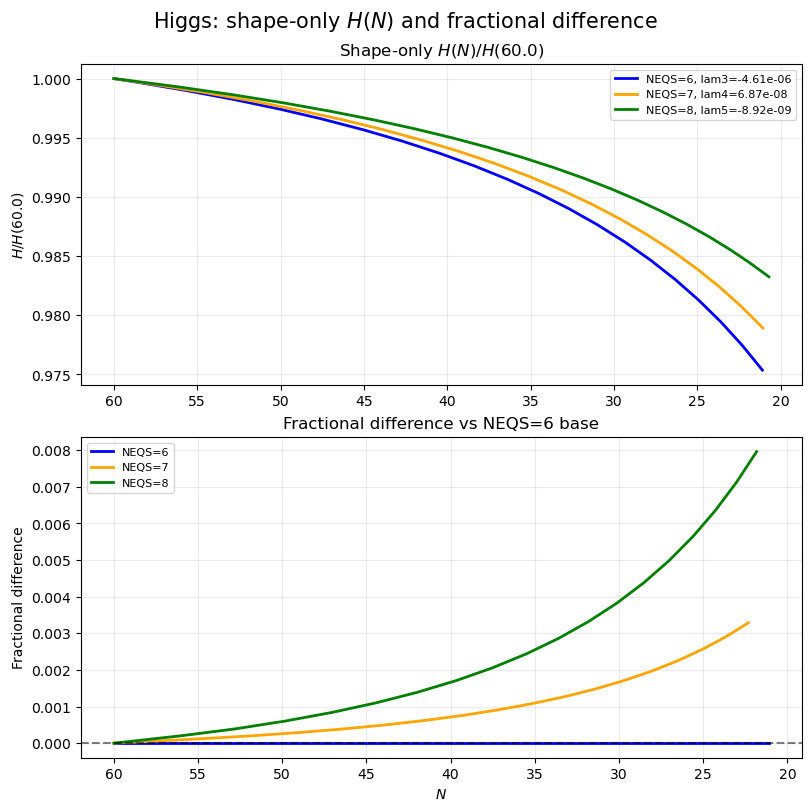

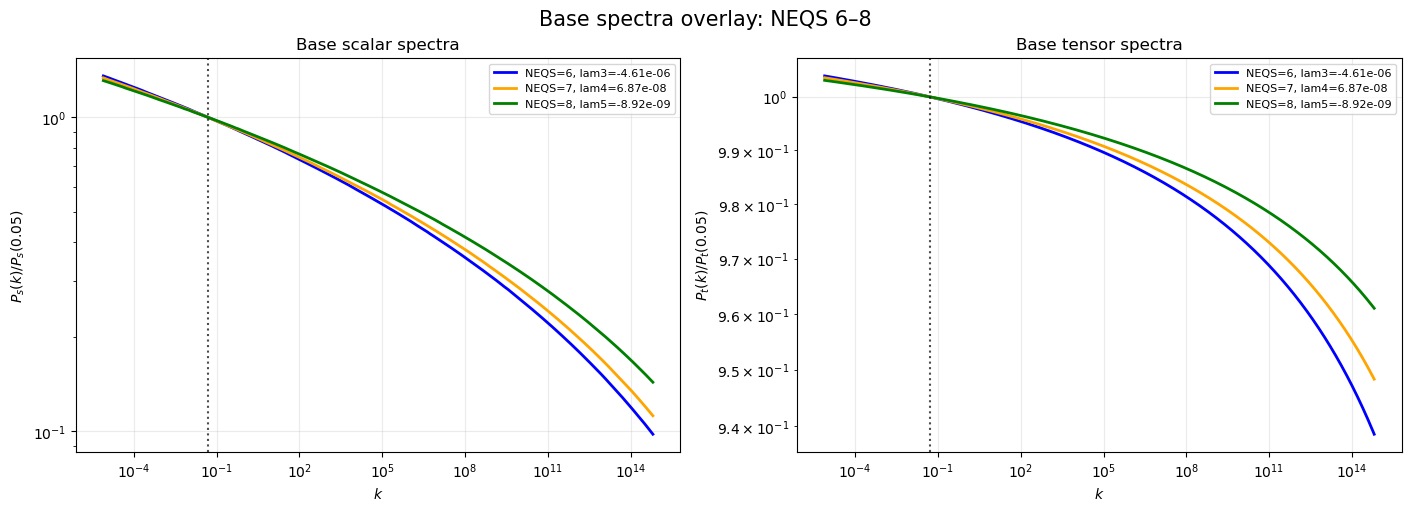

In [23]:
plot_H_shape_only_with_frac_error_limitedN(
    base_path_root=base_path_root,
    save_name="higgs_H_shape_only_with_frac_error_limitedN.png",
    suptitle=r"Higgs: shape-only $H(N)$ and fractional difference",
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
)

plot_base_spectra_overlay_k(
    base_path_root=base_path_root,
    normalize=True,
    k_ref=0.05,
    save_name="base_spectra_overlay_neqs6_8.png",
)

## SPECTRUM DERIVATIVE CHECK

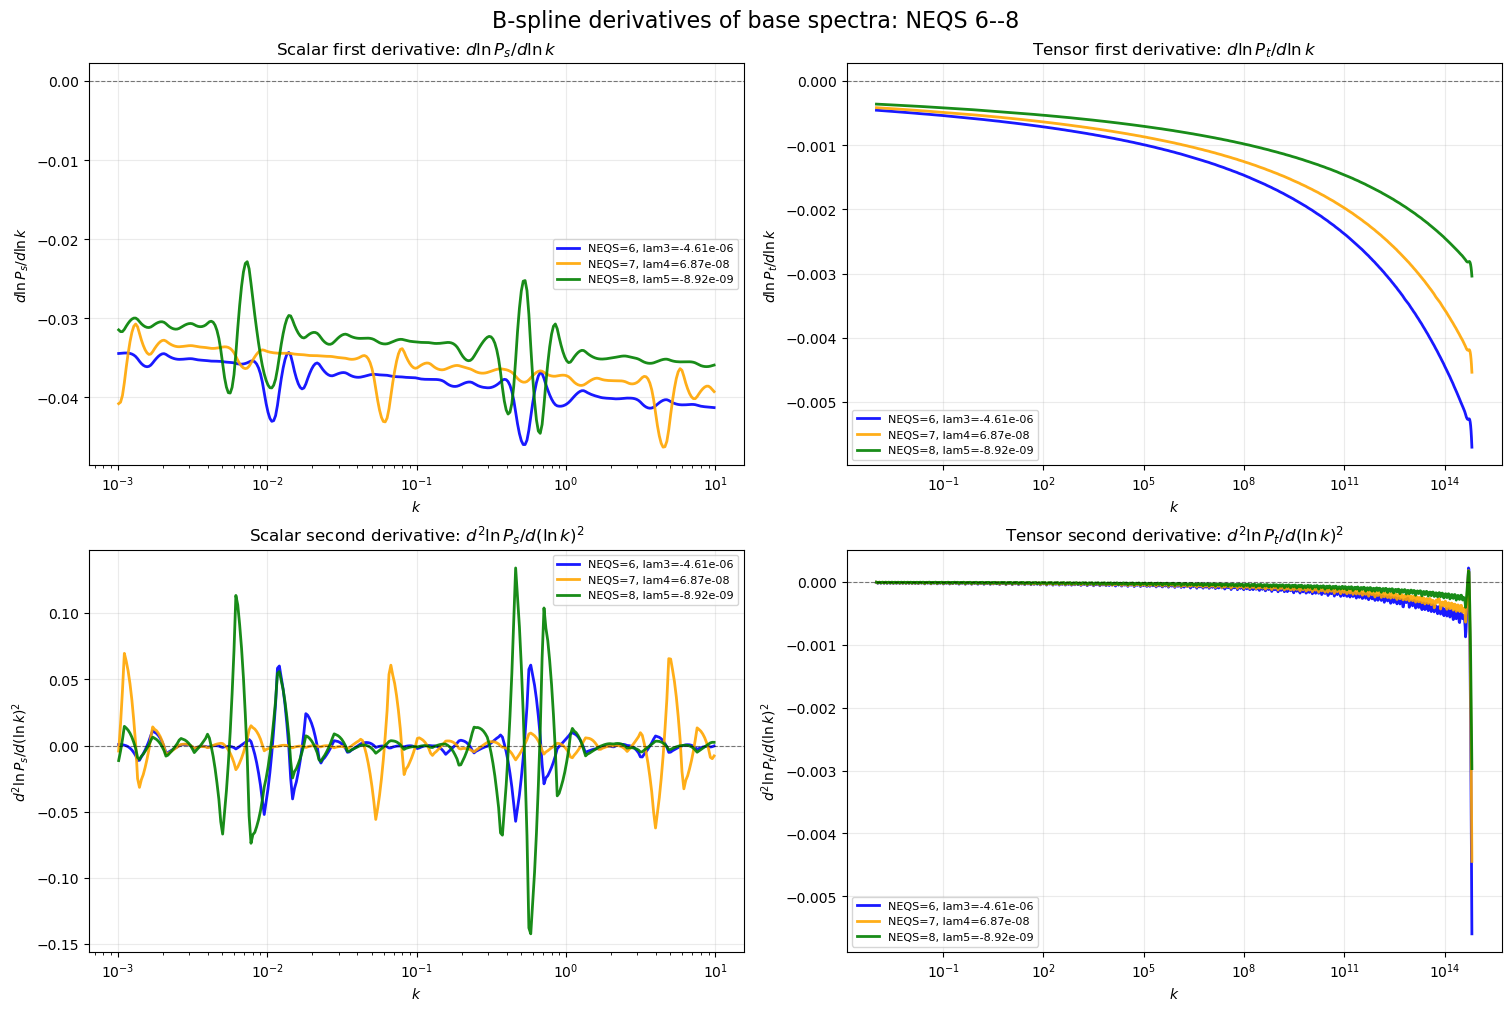

In [29]:
# def plot_base_spectra_derivatives_bspline_2x2(
#     base_path_root,
#     base_params=None,
#     k_min_plot=None,
#     k_max_plot=None,
#     smoothing=0.0,
#     save_name=None,
# ):

def plot_base_spectra_derivatives_bspline_2x2(
    base_path_root,
    base_params=None,
    k_min_plot=None,
    k_max_plot_s=10.0,
    k_max_plot_t=None,
    smoothing=0.0,
    save_name=None,
):
    
    
    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

#     colors = {
#         6: "blue",
#         7: "orange",
#         8: "green",
#     }

#     def folder_for(NEQS, param_name, value):
#         val_str = f"{value:.10e}"
#         return os.path.join(
#             base_path_root,
#             f"neqs{NEQS}",
#             f"{param_name}_{val_str}"
#         )

#     def load_specs(NEQS, param_name, value):
#         folder = folder_for(NEQS, param_name, value)

#         s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
#         t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

#         k_s = s[:, 0]
#         Ps = np.abs(s[:, 1])

#         k_t = t[:, 0]
#         Pt = np.abs(t[:, 1])

#         return k_s, Ps, k_t, Pt

    def prepare_log_spline(k, P, smoothing=0.0):
        k = np.asarray(k)
        P = np.asarray(P)

        mask = (k > 0) & (P > 0) & np.isfinite(k) & np.isfinite(P)
        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

#         x_unique, idx = np.unique(x, return_index=True)
#         y_unique = y[idx] #would keep 1st occurence of duplicate

        x_unique = np.unique(x)
        y_unique = np.array([np.mean(y[x == xu]) for xu in x_unique]) #averages duplicates

        spl = UnivariateSpline(x_unique, y_unique, s=smoothing, k=3)

        d1 = spl.derivative(1)(x_unique)
        d2 = spl.derivative(2)(x_unique)

        return np.exp(x_unique), d1, d2

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_d1Ps, ax_d1Pt = axes[0]
    ax_d2Ps, ax_d2Pt = axes[1]

    for NEQS, (param_name, value) in base_params.items():
        k_s, Ps, k_t, Pt = load_specs(NEQS, param_name, value)

        k_s_use, d1Ps, d2Ps = prepare_log_spline(k_s, Ps, smoothing=smoothing)
        k_t_use, d1Pt, d2Pt = prepare_log_spline(k_t, Pt, smoothing=smoothing)

        mask_s = np.ones_like(k_s_use, dtype=bool)
        mask_t = np.ones_like(k_t_use, dtype=bool)

        if k_min_plot is not None:
            mask_s &= k_s_use >= k_min_plot
            mask_t &= k_t_use >= k_min_plot

#         if k_max_plot is not None:
#             mask_s &= k_s_use <= k_max_plot
#             mask_t &= k_t_use <= k_max_plot
            
        if k_max_plot_s is not None:
            mask_s &= k_s_use <= k_max_plot_s

        if k_max_plot_t is not None:
            mask_t &= k_t_use <= k_max_plot_t

        label = rf"NEQS={NEQS}, {param_name}={value:.2e}"
        color = colors.get(NEQS, None)

        ax_d1Ps.semilogx(
            k_s_use[mask_s], d1Ps[mask_s],
            color=color, lw=2.0, alpha=0.9, label=label
        )

        ax_d1Pt.semilogx(
            k_t_use[mask_t], d1Pt[mask_t],
            color=color, lw=2.0, alpha=0.9, label=label
        )

        ax_d2Ps.semilogx(
            k_s_use[mask_s], d2Ps[mask_s],
            color=color, lw=2.0, alpha=0.9, label=label
        )

        ax_d2Pt.semilogx(
            k_t_use[mask_t], d2Pt[mask_t],
            color=color, lw=2.0, alpha=0.9, label=label
        )

    ax_d1Ps.set_title(r"Scalar first derivative: $d\ln P_s / d\ln k$")
    ax_d1Pt.set_title(r"Tensor first derivative: $d\ln P_t / d\ln k$")
    ax_d2Ps.set_title(r"Scalar second derivative: $d^2\ln P_s / d(\ln k)^2$")
    ax_d2Pt.set_title(r"Tensor second derivative: $d^2\ln P_t / d(\ln k)^2$")

    for ax in axes.ravel():
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_xlabel(r"$k$")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)

    ax_d1Ps.set_ylabel(r"$d\ln P_s / d\ln k$")
    ax_d1Pt.set_ylabel(r"$d\ln P_t / d\ln k$")
    ax_d2Ps.set_ylabel(r"$d^2\ln P_s / d(\ln k)^2$")
    ax_d2Pt.set_ylabel(r"$d^2\ln P_t / d(\ln k)^2$")

    fig.suptitle(
        rf"B-spline derivatives of base spectra: NEQS 6--8",
        fontsize=16,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()
    
#Run it like so using. B-splines    
# plot_base_spectra_derivatives_bspline_2x2(
#     base_path_root=base_path_root,
#     k_min_plot=None,
#     k_max_plot=10.0,
#     smoothing=0.0,
#     save_name="base_spectra_derivatives_neqs6_8.png",
# )


plot_base_spectra_derivatives_bspline_2x2(
    base_path_root=base_path_root,
    k_min_plot=None,
    k_max_plot_s=10.0,
    k_max_plot_t=None,   # full tensor k range
    smoothing=0.0,
    save_name="base_spectra_derivatives_neqs6_8.png",
)

# COMPARE ORIGINAL VS SHIFTED N TRAJECTORIES

NEQS=7: original_N_end=941.8371, ref_N_end=939.1636, deltaN=2.6735, N range=(0.0000, 60.0000), shifted N range=(-2.6735, 57.3265)
NEQS=8: original_N_end=946.3497, ref_N_end=939.1636, deltaN=7.1862, N range=(0.0000, 60.0000), shifted N range=(-7.1862, 52.8138)


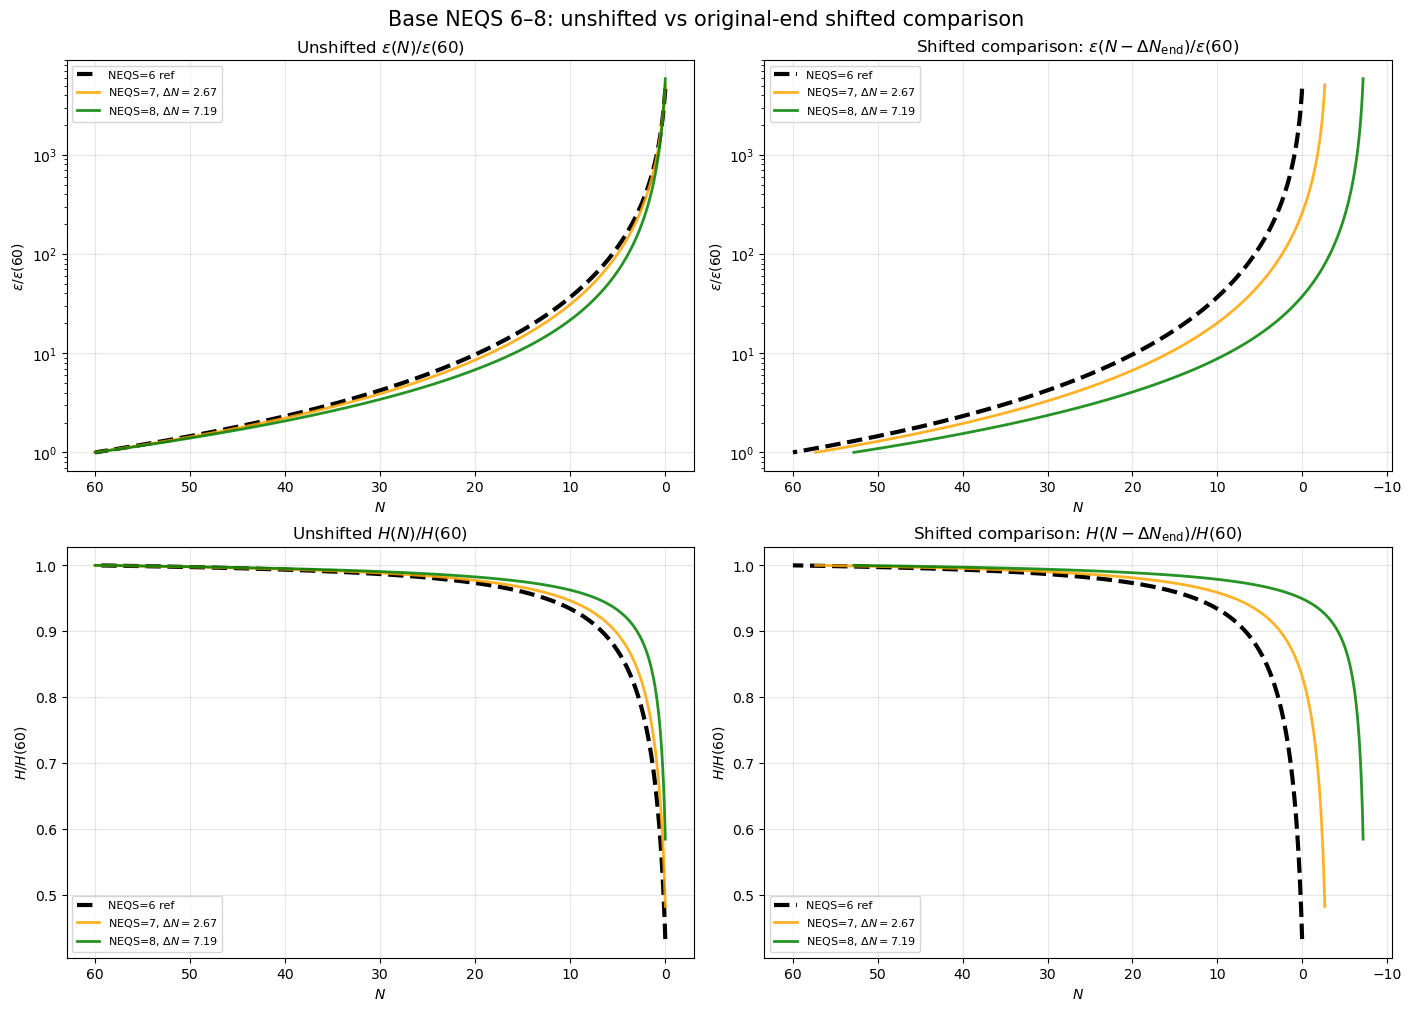

In [43]:
def plot_unshifted_vs_shifted_eps_H_base_neqs6_8(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
    N_norm_ref=60.0,
    save_name=None,
):

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    def load_path_N_eps_H(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        folder = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )
        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
        )

        data = pd.read_csv(file_path, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]
        H = data[:, 1]

        order = np.argsort(N)
        return N[order], eps[order], H[order]

    # Reference model
    ref_row = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS
    ].iloc[0]

    ref_N_end = ref_row["original_N_end"]

    ref_param, ref_value = base_params[ref_NEQS]

    N_ref_curve, eps_ref, H_ref = load_path_N_eps_H(
        ref_NEQS, ref_param, ref_value
    )

    N_ref, eps_ref_norm, eps_ref_at_60 = normalize_curve_at_Nref(
        N_ref_curve, eps_ref, N_ref=N_norm_ref
    )

    _, H_ref_norm, H_ref_at_60 = normalize_curve_at_Nref(
        N_ref_curve, H_ref, N_ref=N_norm_ref
    )

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 10), constrained_layout=True
    )

    ax_eps_un, ax_eps_sh = axes[0]
    ax_H_un, ax_H_sh = axes[1]

    ref_label = f"NEQS={ref_NEQS} ref"

    ax_eps_un.plot(
        N_ref, eps_ref_norm,
        color="black", lw=3, ls="--", label=ref_label
    )
    ax_eps_sh.plot(
        N_ref, eps_ref_norm,
        color="black", lw=3, ls="--", label=ref_label
    )

    ax_H_un.plot(
        N_ref, H_ref_norm,
        color="black", lw=3, ls="--", label=ref_label
    )
    ax_H_sh.plot(
        N_ref, H_ref_norm,
        color="black", lw=3, ls="--", label=ref_label
    )

    for NEQS, (param_name, value) in base_params.items():
        if NEQS == ref_NEQS:
            continue

        row = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS
        ].iloc[0]

        #I define original N - Nref. I expect this to be a positive deltaN
        #To go back to original I would need to subtract deltaN
        deltaN = row["original_N_end"] - ref_N_end 

        N, eps, H = load_path_N_eps_H(NEQS, param_name, value)

        N_use, eps_norm, eps_at_60 = normalize_curve_at_Nref(
            N, eps, N_ref=N_norm_ref
        )

        _, H_norm, H_at_60 = normalize_curve_at_Nref(
            N, H, N_ref=N_norm_ref
        )

        # If this model has more total e-folds than the reference which it does,
        # subtract deltaN to align it with the reference trajectory.
        N_shifted = N_use - deltaN

        label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"

        ax_eps_un.plot(
            N_use, eps_norm,
            color=colors.get(NEQS), lw=2, alpha=0.85, label=label
        )
        ax_H_un.plot(
            N_use, H_norm,
            color=colors.get(NEQS), lw=2, alpha=0.85, label=label
        )

        ax_eps_sh.plot(
            N_shifted, eps_norm,
            color=colors.get(NEQS), lw=2, alpha=0.85, label=label
        )
        ax_H_sh.plot(
            N_shifted, H_norm,
            color=colors.get(NEQS), lw=2, alpha=0.85, label=label
        )

        print(
            f"NEQS={NEQS}: "
            f"original_N_end={row['original_N_end']:.4f}, "
            f"ref_N_end={ref_N_end:.4f}, "
            f"deltaN={deltaN:.4f}, "
            f"N range=({N_use.min():.4f}, {N_use.max():.4f}), "
            f"shifted N range=({N_shifted.min():.4f}, {N_shifted.max():.4f})"
        )

    ax_eps_un.set_title(r"Unshifted $\epsilon(N)/\epsilon(60)$")
#     ax_eps_sh.set_title(r"Shifted $\epsilon(N-\Delta N_{\rm end})/\epsilon(60)$")

    ax_H_un.set_title(r"Unshifted $H(N)/H(60)$")
#     ax_H_sh.set_title(r"Shifted $H(N-\Delta N_{\rm end})/H(60)$")

    
    ax_eps_sh.set_title(r"Shifted comparison: $\epsilon(N-\Delta N_{\rm end})/\epsilon(60)$")
    ax_H_sh.set_title(r"Shifted comparison: $H(N-\Delta N_{\rm end})/H(60)$")


    for ax in [ax_eps_un, ax_eps_sh]:
        ax.set_yscale("log")
        ax.set_ylabel(r"$\epsilon/\epsilon(60)$")

    for ax in [ax_H_un, ax_H_sh]:
        ax.set_ylabel(r"$H/H(60)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N$")
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    fig.suptitle(
        "Base NEQS 6–8: unshifted vs original-end shifted comparison",
        fontsize=15,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()
    
    
plot_unshifted_vs_shifted_eps_H_base_neqs6_8(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    N_norm_ref=60.0,
    save_name="unshifted_vs_shifted_eps_H_base_neqs6_8.png",
)

The plot directly above shifts the normalized trajectory by the amount relative to that for the reference model which is NEQs=6.

NEQS=7: deltaN=2.6735, N shifted range=(-2.6735, 57.3265), N plotted range=(20.9606, 57.3265), max |frac eps|=29.8119%, max |frac H|=0.7435%
NEQS=8: deltaN=7.1862, N shifted range=(-7.1862, 52.8138), N plotted range=(21.3423, 52.8138), max |frac eps|=56.1239%, max |frac H|=1.4247%


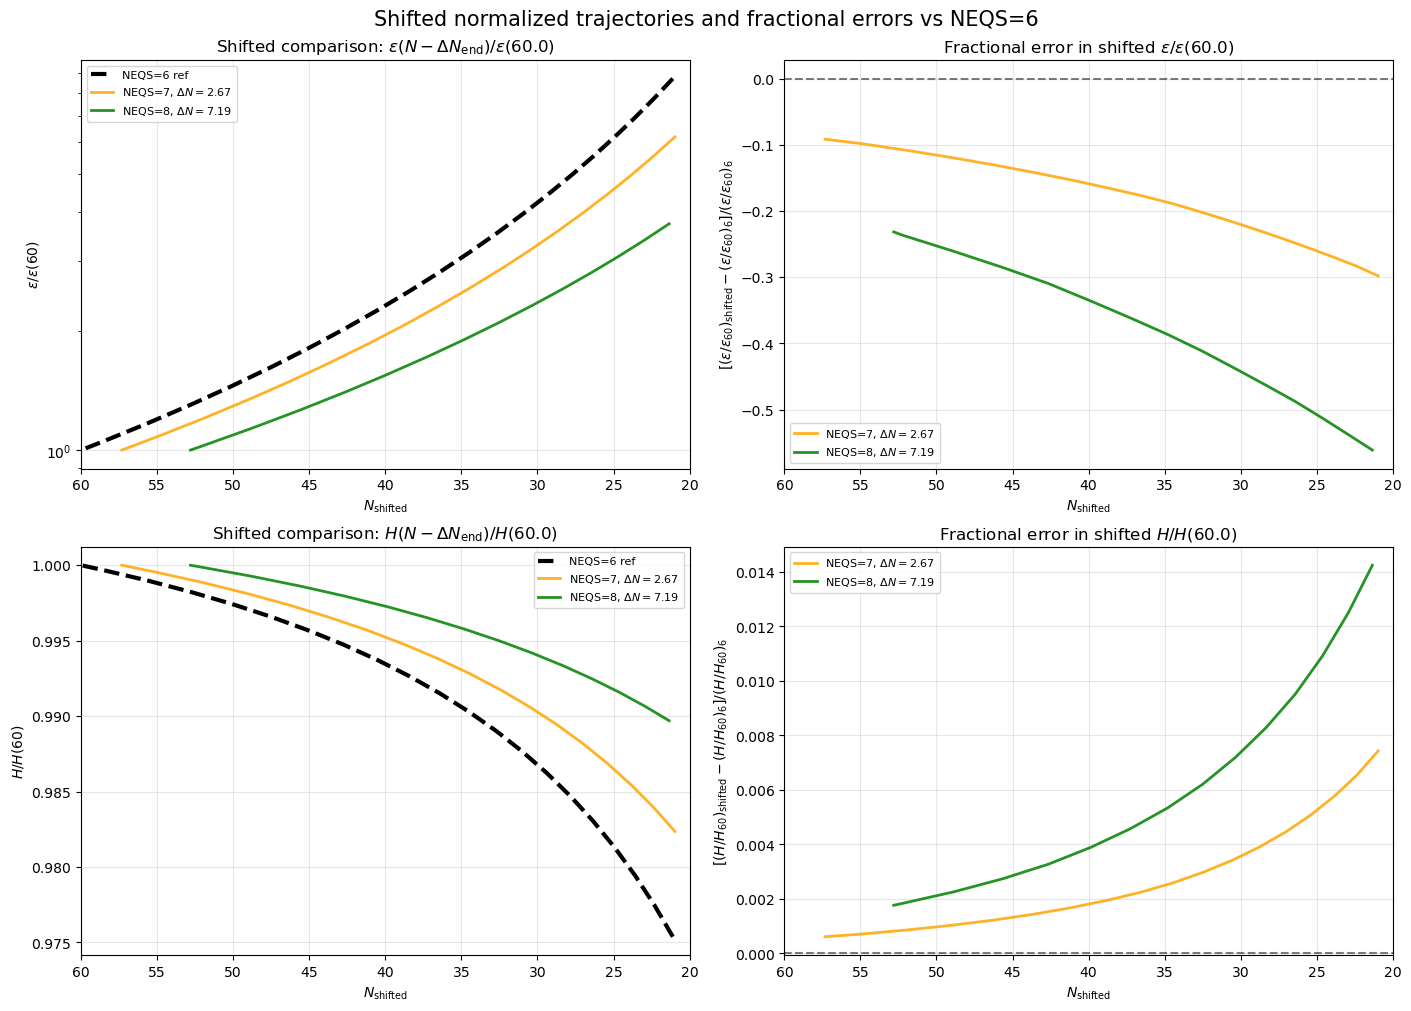

 NEQS   deltaN  N_plot_min  N_plot_max  max_abs_frac_eps_pct  N_at_max_eps_error  median_abs_frac_eps_pct  rms_frac_eps_pct  p95_abs_frac_eps_pct  max_abs_frac_H_pct  N_at_max_H_error  median_abs_frac_H_pct  rms_frac_H_pct  p95_abs_frac_H_pct
    7 2.673499   20.960589   57.326501             29.811854           20.960589                18.285463         19.825350             28.581464            0.743480         20.960589               0.241824        0.363762            0.668289
    8 7.186161   21.342329   52.813839             56.123915           21.342329                38.659198         40.250194             54.478101            1.424716         21.342329               0.534377        0.740500            1.301973


In [50]:
def plot_shifted_eps_H_with_fractional_errors_base_neqs6_8(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
    N_norm_ref=60.0,
    N_min_plot=20.0,
    N_max_plot=60.0,
    save_name=None,
):

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    def load_path_N_eps_H(NEQS, param_name, value):
        data = load_path_data(NEQS, param_name, value)

        N = data[:, NEQS]
        eps = data[:, 2]
        H = data[:, 1]

        N, eps = prepare_increasing(N, eps)
        _, H = prepare_increasing(data[:, NEQS], H)

        return N, eps, H

    # Reference model
    ref_row = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS
    ].iloc[0]

    ref_N_end = ref_row["original_N_end"]

    ref_param, ref_value = base_params[ref_NEQS]

    N_ref_raw, eps_ref_raw, H_ref_raw = load_path_N_eps_H(
        ref_NEQS, ref_param, ref_value
    )

    N_ref, eps_ref_norm, _ = normalize_curve_at_Nref(
        N_ref_raw, eps_ref_raw, N_ref=N_norm_ref
    )

    _, H_ref_norm, _ = normalize_curve_at_Nref(
        N_ref_raw, H_ref_raw, N_ref=N_norm_ref
    )

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 10), constrained_layout=True
    )

    ax_eps_shift, ax_eps_frac = axes[0]
    ax_H_shift, ax_H_frac = axes[1]

    # Reference masks for shifted plot window
    ref_plot_mask = (N_ref >= N_min_plot) & (N_ref <= N_max_plot)

    ref_label = f"NEQS={ref_NEQS} ref"

    # Left column: exact shifted comparison style
    ax_eps_shift.plot(
        N_ref[ref_plot_mask],
        eps_ref_norm[ref_plot_mask],
        color="black",
        lw=3,
        ls="--",
        label=ref_label,
    )

    ax_H_shift.plot(
        N_ref[ref_plot_mask],
        H_ref_norm[ref_plot_mask],
        color="black",
        lw=3,
        ls="--",
        label=ref_label,
    )

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        if NEQS == ref_NEQS:
            continue

        row = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS
        ].iloc[0]

        deltaN = row["original_N_end"] - ref_N_end

        N_raw, eps_raw, H_raw = load_path_N_eps_H(
            NEQS, param_name, value
        )

        N_use, eps_norm, _ = normalize_curve_at_Nref(
            N_raw, eps_raw, N_ref=N_norm_ref
        )

        _, H_norm, _ = normalize_curve_at_Nref(
            N_raw, H_raw, N_ref=N_norm_ref
        )

        # Same shift convention as your attached plot
        N_shifted = N_use - deltaN

        label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"

        # Only show 60 down to 20
        plot_mask = (
            (N_shifted >= N_min_plot) &
            (N_shifted <= N_max_plot)
        )

        N_plot = N_shifted[plot_mask]
        eps_plot = eps_norm[plot_mask]
        H_plot = H_norm[plot_mask]

        # Left column: shifted normalized curves
        ax_eps_shift.plot(
            N_plot,
            eps_plot,
            color=colors.get(NEQS),
            lw=2,
            alpha=0.85,
            label=label,
        )

        ax_H_shift.plot(
            N_plot,
            H_plot,
            color=colors.get(NEQS),
            lw=2,
            alpha=0.85,
            label=label,
        )

        # Right column: fractional errors on the same shifted grid
        eps_ref_interp = np.interp(N_plot, N_ref, eps_ref_norm)
        H_ref_interp = np.interp(N_plot, N_ref, H_ref_norm)

        frac_eps = (eps_plot - eps_ref_interp) / eps_ref_interp
        frac_H = (H_plot - H_ref_interp) / H_ref_interp

        ax_eps_frac.plot(
            N_plot,
            frac_eps,
            color=colors.get(NEQS),
            lw=2,
            alpha=0.85,
            label=label,
        )

        ax_H_frac.plot(
            N_plot,
            frac_H,
            color=colors.get(NEQS),
            lw=2,
            alpha=0.85,
            label=label,
        )

        abs_frac_eps = np.abs(frac_eps)
        abs_frac_H = np.abs(frac_H)

        i_eps_max = np.nanargmax(abs_frac_eps)
        i_H_max = np.nanargmax(abs_frac_H)

        rows.append({
            "NEQS": NEQS,
            "deltaN": deltaN,
            "N_plot_min": N_plot.min(),
            "N_plot_max": N_plot.max(),

            "max_abs_frac_eps_pct": 100 * abs_frac_eps[i_eps_max],
            "N_at_max_eps_error": N_plot[i_eps_max],
            "median_abs_frac_eps_pct": 100 * np.nanmedian(abs_frac_eps),
            "rms_frac_eps_pct": 100 * np.sqrt(np.nanmean(frac_eps**2)),
            "p95_abs_frac_eps_pct": 100 * np.nanpercentile(abs_frac_eps, 95),

            "max_abs_frac_H_pct": 100 * abs_frac_H[i_H_max],
            "N_at_max_H_error": N_plot[i_H_max],
            "median_abs_frac_H_pct": 100 * np.nanmedian(abs_frac_H),
            "rms_frac_H_pct": 100 * np.sqrt(np.nanmean(frac_H**2)),
            "p95_abs_frac_H_pct": 100 * np.nanpercentile(abs_frac_H, 95),
        })
            
        print(
        f"NEQS={NEQS}: "
        f"deltaN={deltaN:.4f}, "
        f"N shifted range=({N_shifted.min():.4f}, {N_shifted.max():.4f}), "
        f"N plotted range=({N_plot.min():.4f}, {N_plot.max():.4f}), "
        f"max |frac eps|={100*np.nanmax(np.abs(frac_eps)):.4f}%, "
        f"max |frac H|={100*np.nanmax(np.abs(frac_H)):.4f}%"
    )

    # Titles
    ax_eps_shift.set_title(
        rf"Shifted comparison: $\epsilon(N-\Delta N_{{\rm end}})/\epsilon({N_norm_ref})$"
    )
    ax_H_shift.set_title(
        rf"Shifted comparison: $H(N-\Delta N_{{\rm end}})/H({N_norm_ref})$"
    )

    ax_eps_frac.set_title(
        rf"Fractional error in shifted $\epsilon/\epsilon({N_norm_ref})$"
    )
    ax_H_frac.set_title(
        rf"Fractional error in shifted $H/H({N_norm_ref})$"
    )

    # Labels
    ax_eps_shift.set_ylabel(r"$\epsilon/\epsilon(60)$")
    ax_H_shift.set_ylabel(r"$H/H(60)$")

    ax_eps_frac.set_ylabel(
        r"$[(\epsilon/\epsilon_{60})_{\rm shifted}-(\epsilon/\epsilon_{60})_6]"
        r"/(\epsilon/\epsilon_{60})_6$"
    )
    ax_H_frac.set_ylabel(
        r"$[(H/H_{60})_{\rm shifted}-(H/H_{60})_6]/(H/H_{60})_6$"
    )

    # Log scale only for epsilon shifted plot
    ax_eps_shift.set_yscale("log")

    # Zero lines for fractional error plots
    for ax in [ax_eps_frac, ax_H_frac]:
        ax.axhline(0.0, color="black", ls="--", alpha=0.5)

    for ax in axes.ravel():
        ax.set_xlabel(r"$N_{\rm shifted}$")
        ax.set_xlim(N_max_plot, N_min_plot)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(
        "Shifted normalized trajectories and fractional errors vs NEQS=6",
        fontsize=15,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

    return pd.DataFrame(rows)



frac_df = plot_shifted_eps_H_with_fractional_errors_base_neqs6_8(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    N_norm_ref=60.0,
    N_min_plot=20.0,
    N_max_plot=60.0,
    save_name="shifted_eps_H_with_fractional_errors_neqs6_8.png",
)

print(frac_df.to_string(index=False))

As you can see above the plot for the shifted normalized epsilon is larger while that is not the case for H at all. So, below I went ahead and inspected the raw slow-roll parameters. I also have a toggle that can normalize or un-normalize H. I think H is different because H does get normalized in the code for each model differently, so if I want to compare shape I need to account for that normalization but the slow-roll parameters are not independently normalized.

NEQS=6: original_N_end=939.1636, N_recon=(0.0000, 60.0000), N_restored=(939.1636, 999.1636)
NEQS=7: original_N_end=941.8371, N_recon=(0.0000, 60.0000), N_restored=(941.8371, 1001.8371)
NEQS=8: original_N_end=946.3497, N_recon=(0.0000, 60.0000), N_restored=(946.3497, 1006.3497)


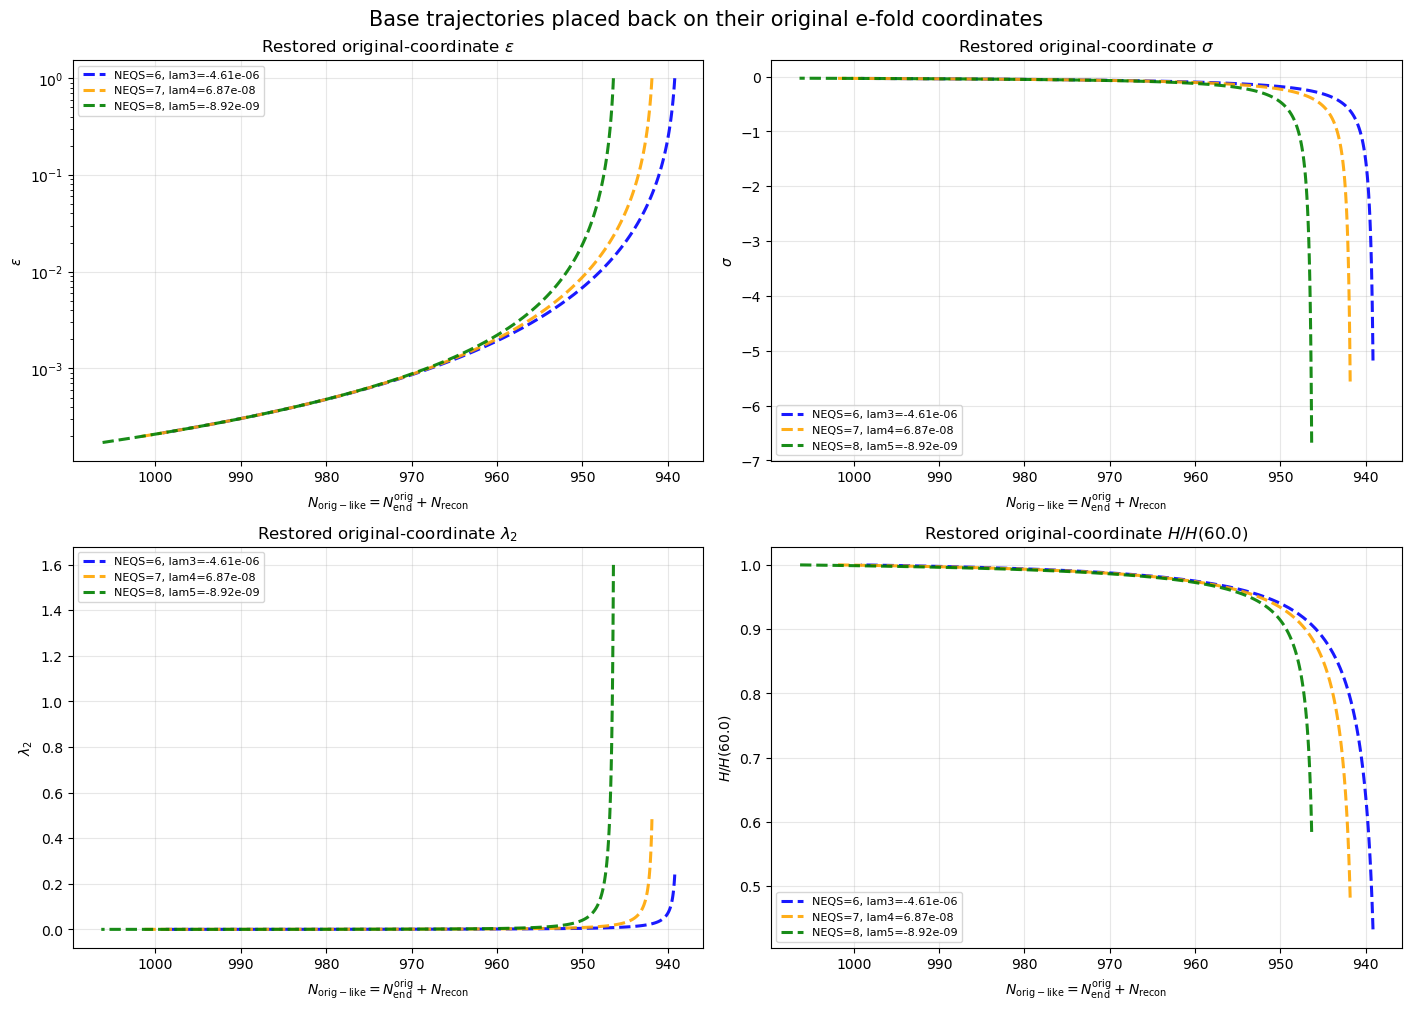

In [59]:
def plot_restored_original_trajectories_base_neqs6_8(
    base_path_root,
    base_summary_df,
    base_params=None,
    normalize_H=True,
    N_norm_ref=60.0,
    save_name=None,
):
    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    def load_path_N_3srp_H(NEQS, param_name, value):
        data = load_path_data(NEQS, param_name, value)

        N = data[:, NEQS]
        eps = data[:, 2]
        sigma = data[:, 3]
        lam2 = data[:, 4]
        H = data[:, 1]

        N, eps = prepare_increasing(N, eps)
        _, sigma = prepare_increasing(data[:, NEQS], sigma)
        _, lam2 = prepare_increasing(data[:, NEQS], lam2)
        _, H = prepare_increasing(data[:, NEQS], H)

        return N, eps, sigma, lam2, H

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 10), constrained_layout=True
    )

    ax_eps, ax_sig = axes[0]
    ax_lam2, ax_H = axes[1]

    for NEQS, (param_name, value) in base_params.items():
        row = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS
        ].iloc[0]
        
        #so this is the original N end from 1000 efolds down to where eps=1
        original_N_end = row["original_N_end"]

        #N_recon is loosely 60 for each but their 
        #inferred/original total inflation duration differs
        N_recon, eps, sigma, lam2, H = load_path_N_3srp_H(
            NEQS, param_name, value
        )
        
        #N restored is to approximate where 
        #this reconstructed window sat inside the original trajectory
        N_restored = original_N_end + N_recon

        #we might want to normalize H cause we do normalize it differently for each model
        #remember we explicitly rescale the reconstructed Hubble trajectory by the final 
        #evolved normalization y[1]
        
        if normalize_H:
            N_H, H_plot, H_at_ref = normalize_curve_at_Nref(
                N_recon, H, N_ref=N_norm_ref
            )

            H_ylabel = rf"$H/H({N_norm_ref})$"
            H_title = rf"Restored original-coordinate $H/H({N_norm_ref})$"

        else:

            N_H, H_plot = prepare_increasing(N_recon, H)

            H_ylabel = r"$H$"
            H_title = r"Restored original-coordinate $H$"

        # Restore original coordinate
        N_H_restored = original_N_end + N_H


        label = rf"NEQS={NEQS}, {param_name}={value:.2e}"

        ax_eps.plot(
            N_restored,
            eps,
            color=colors.get(NEQS),
            lw=2.2,
            alpha=0.9,
            label=label,linestyle="--",
        )

        ax_sig.plot(
            N_restored,
            sigma,
            color=colors.get(NEQS),
            lw=2.2,
            alpha=0.9,
            label=label,linestyle="--",
        )

        ax_lam2.plot(
            N_restored,
            lam2,
            color=colors.get(NEQS),
            lw=2.2,
            alpha=0.9,
            label=label,linestyle="--",
        )

        ax_H.plot(
            N_H_restored,
            H_plot,
            color=colors.get(NEQS),
            lw=2.2,
            alpha=0.9,
            label=label,linestyle="--",
        )
        


        print(
            f"NEQS={NEQS}: "
            f"original_N_end={original_N_end:.4f}, "
            f"N_recon=({N_recon.min():.4f}, {N_recon.max():.4f}), "
            f"N_restored=({N_restored.min():.4f}, {N_restored.max():.4f})"
        )

    ax_eps.set_title(r"Restored original-coordinate $\epsilon$")
    ax_sig.set_title(r"Restored original-coordinate $\sigma$")
    ax_lam2.set_title(r"Restored original-coordinate $\lambda_2$")
#     ax_H.set_title(rf"Restored original-coordinate $H/H({N_norm_ref})$")
    ax_H.set_title(H_title)
    ax_eps.set_yscale("log")

    for ax in axes.ravel():
#         ax.set_xlabel(
#             r"Approximate original e-fold coordinate "
#             r"$N_{\epsilon=1}^{\rm orig}+N_{\rm recon}$"
#         )
        ax.set_xlabel(r"$N_{\rm orig-like}=N_{\rm end}^{\rm orig}+N_{\rm recon}$")
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)
    ax.set_xlabel(r"$N_{\rm orig-like}=N_{\rm end}^{\rm orig}+N_{\rm recon}$")
    ax_eps.set_ylabel(r"$\epsilon$")
    ax_sig.set_ylabel(r"$\sigma$")
    ax_lam2.set_ylabel(r"$\lambda_2$")
#     ax_H.set_ylabel(rf"$H/H({N_norm_ref})$")
    ax_H.set_ylabel(H_ylabel)

#     fig.suptitle(
#         r"Restored original-coordinate base trajectories: NEQS 6--8",
#         fontsize=15,
#     )
    
    fig.suptitle(
    "Base trajectories placed back on their original e-fold coordinates",
    fontsize=15,
)

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()
    
    
plot_restored_original_trajectories_base_neqs6_8(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    normalize_H=True,
)

So if we remove the H scaling to inspect the shape and its similarity but keep srps the same we see basically the lines on the same trajectory but their trajctory are of different lengths, we should do a second plot that compares fractional errors in each of thee cases.

In [60]:
def plot_restored_original_fractional_errors_base_neqs6_8(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
    normalize_H=True,
    N_norm_ref=60.0,
    denom_floor=1e-30,
    save_name=None,
):

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    def load_path_N_3srp_H(NEQS, param_name, value):
        data = load_path_data(NEQS, param_name, value)

        N = data[:, NEQS]
        eps = data[:, 2]
        sigma = data[:, 3]
        lam2 = data[:, 4]
        H = data[:, 1]

        N, eps = prepare_increasing(N, eps)
        _, sigma = prepare_increasing(data[:, NEQS], sigma)
        _, lam2 = prepare_increasing(data[:, NEQS], lam2)
        _, H = prepare_increasing(data[:, NEQS], H)

        return N, eps, sigma, lam2, H

    def safe_frac(model, ref):
        return (model - ref) / np.where(
            np.abs(ref) > denom_floor,
            ref,
            np.nan,
        )

    # Reference
    ref_row = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS
    ].iloc[0]

    ref_original_N_end = ref_row["original_N_end"]

    ref_param, ref_value = base_params[ref_NEQS]

    N_ref_recon, eps_ref, sigma_ref, lam2_ref, H_ref = load_path_N_3srp_H(
        ref_NEQS, ref_param, ref_value
    )

    N_ref_orig = ref_original_N_end + N_ref_recon

    if normalize_H:
        N_ref_H, H_ref_plot, _ = normalize_curve_at_Nref(
            N_ref_recon, H_ref, N_ref=N_norm_ref
        )
        N_ref_H_orig = ref_original_N_end + N_ref_H
        H_ylabel = rf"fractional error in $H/H({N_norm_ref})$"
        H_title = rf"$H/H({N_norm_ref})$ frac. error"
    else:
        N_ref_H, H_ref_plot = prepare_increasing(N_ref_recon, H_ref)
        N_ref_H_orig = ref_original_N_end + N_ref_H
        H_ylabel = r"fractional error in raw $H$"
        H_title = r"Raw $H$ frac. error"

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 10), constrained_layout=True
    )

    ax_eps, ax_sig = axes[0]
    ax_lam2, ax_H = axes[1]

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        if NEQS == ref_NEQS:
            continue

        row = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS
        ].iloc[0]

        original_N_end = row["original_N_end"]

        N_recon, eps, sigma, lam2, H = load_path_N_3srp_H(
            NEQS, param_name, value
        )

        N_orig = original_N_end + N_recon

        if normalize_H:
            N_H, H_plot, _ = normalize_curve_at_Nref(
                N_recon, H, N_ref=N_norm_ref
            )
        else:
            N_H, H_plot = prepare_increasing(N_recon, H)

        N_H_orig = original_N_end + N_H

        # Compare each model on its own restored original grid,
        # interpolating the reference onto that grid.
        eps_ref_interp = np.interp(N_orig, N_ref_orig, eps_ref)
        sigma_ref_interp = np.interp(N_orig, N_ref_orig, sigma_ref)
        lam2_ref_interp = np.interp(N_orig, N_ref_orig, lam2_ref)

        H_ref_interp = np.interp(N_H_orig, N_ref_H_orig, H_ref_plot)

        frac_eps = safe_frac(eps, eps_ref_interp)
        frac_sigma = safe_frac(sigma, sigma_ref_interp)
        frac_lam2 = safe_frac(lam2, lam2_ref_interp)
        frac_H = safe_frac(H_plot, H_ref_interp)

        label = rf"NEQS={NEQS}, {param_name}={value:.2e}"

        ax_eps.plot(
            N_orig, frac_eps,
            color=colors.get(NEQS), lw=2.2, alpha=0.9,
            linestyle="--", label=label,
        )

        ax_sig.plot(
            N_orig, frac_sigma,
            color=colors.get(NEQS), lw=2.2, alpha=0.9,
            linestyle="--", label=label,
        )

        ax_lam2.plot(
            N_orig, frac_lam2,
            color=colors.get(NEQS), lw=2.2, alpha=0.9,
            linestyle="--", label=label,
        )

        ax_H.plot(
            N_H_orig, frac_H,
            color=colors.get(NEQS), lw=2.2, alpha=0.9,
            linestyle="--", label=label,
        )

        rows.append({
            "NEQS": NEQS,
            "original_N_end": original_N_end,
            "ref_original_N_end": ref_original_N_end,
            "delta_original_N_end": original_N_end - ref_original_N_end,
            "max_abs_frac_eps_pct": 100 * np.nanmax(np.abs(frac_eps)),
            "max_abs_frac_sigma_pct": 100 * np.nanmax(np.abs(frac_sigma)),
            "max_abs_frac_lam2_pct": 100 * np.nanmax(np.abs(frac_lam2)),
            "max_abs_frac_H_pct": 100 * np.nanmax(np.abs(frac_H)),
            "median_abs_frac_eps_pct": 100 * np.nanmedian(np.abs(frac_eps)),
            "median_abs_frac_sigma_pct": 100 * np.nanmedian(np.abs(frac_sigma)),
            "median_abs_frac_lam2_pct": 100 * np.nanmedian(np.abs(frac_lam2)),
            "median_abs_frac_H_pct": 100 * np.nanmedian(np.abs(frac_H)),
        })

        print(
            f"NEQS={NEQS}: "
            f"delta original N_end={original_N_end - ref_original_N_end:.4f}, "
            f"median |frac eps|={100*np.nanmedian(np.abs(frac_eps)):.3e}%, "
            f"median |frac H|={100*np.nanmedian(np.abs(frac_H)):.3e}%"
        )

    ax_eps.set_title(r"$\epsilon$ fractional error")
    ax_sig.set_title(r"$\sigma$ fractional error")
    ax_lam2.set_title(r"$\lambda_2$ fractional error")
    ax_H.set_title(H_title)

    ax_eps.set_ylabel(r"$(\epsilon-\epsilon_{\rm ref})/\epsilon_{\rm ref}$")
    ax_sig.set_ylabel(r"$(\sigma-\sigma_{\rm ref})/\sigma_{\rm ref}$")
    ax_lam2.set_ylabel(r"$(\lambda_2-\lambda_{2,\rm ref})/\lambda_{2,\rm ref}$")
    ax_H.set_ylabel(H_ylabel)

    for ax in axes.ravel():
        ax.axhline(0.0, color="black", ls="--", alpha=0.5)
        ax.set_xlabel(
            r"$N_{\rm orig-like}=N_{\rm end}^{\rm orig}+N_{\rm recon}$"
        )
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    fig.suptitle(
        "Fractional errors on restored original e-fold coordinates",
        fontsize=15,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

    return pd.DataFrame(rows)

For normalized H I set it equal to True, otherwise it can be False

NEQS=7: delta original N_end=2.6735, median |frac eps|=9.038e+01%, median |frac H|=3.535e+00%
NEQS=8: delta original N_end=7.1862, median |frac eps|=2.589e+02%, median |frac H|=4.101e+00%


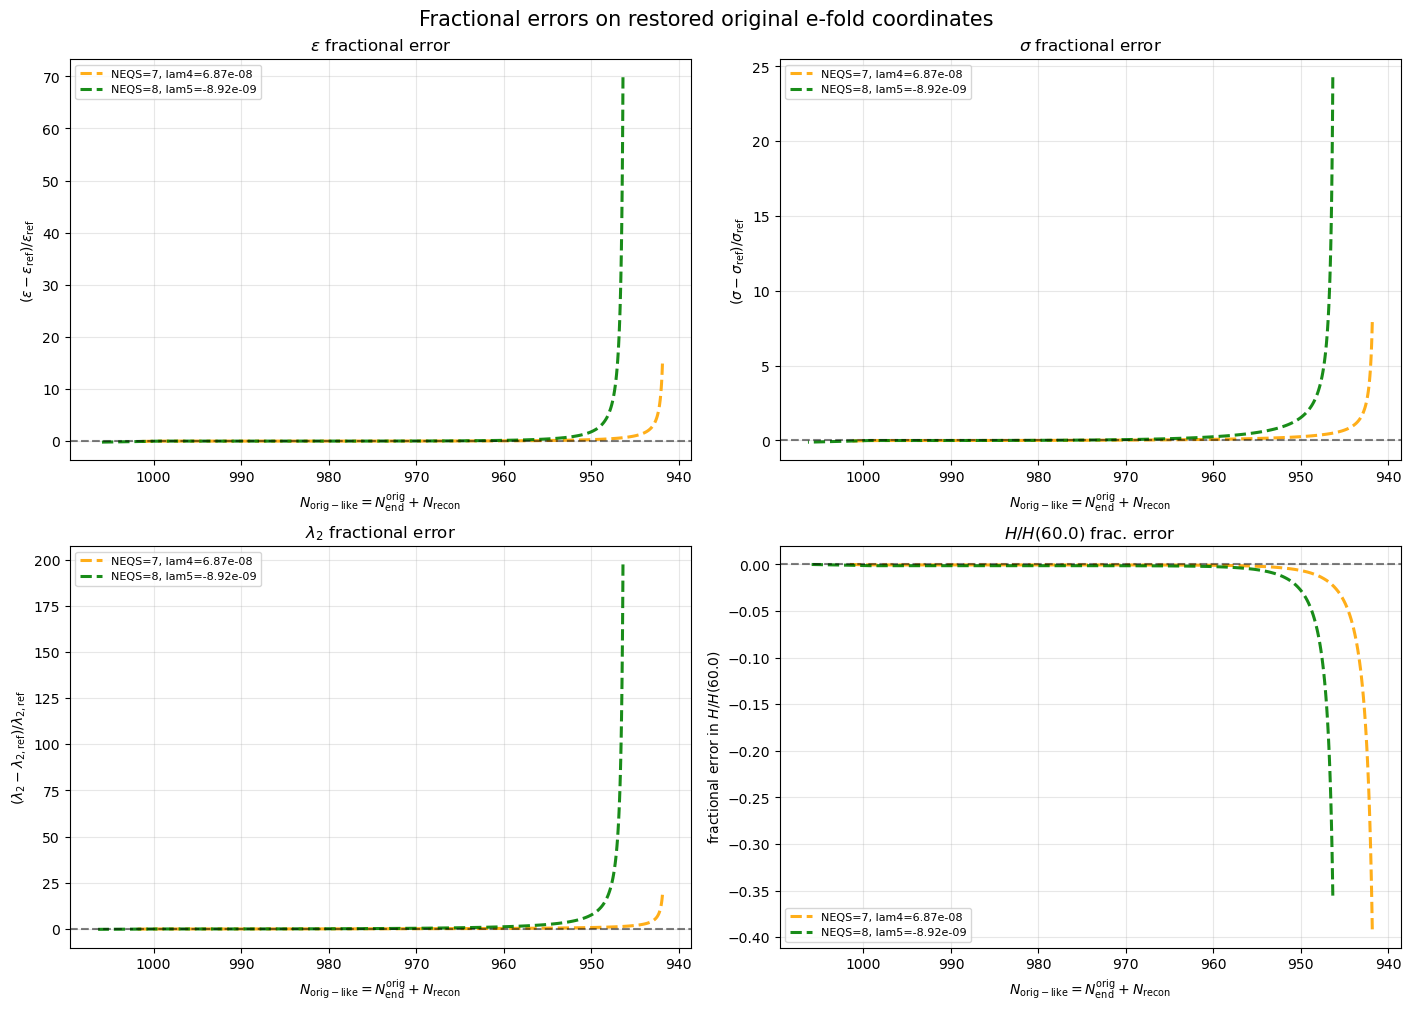

 NEQS  original_N_end  ref_original_N_end  delta_original_N_end  max_abs_frac_eps_pct  max_abs_frac_sigma_pct  max_abs_frac_lam2_pct  max_abs_frac_H_pct  median_abs_frac_eps_pct  median_abs_frac_sigma_pct  median_abs_frac_lam2_pct  median_abs_frac_H_pct
    7      941.837071          939.163572              2.673499           1488.287334              791.640979            1851.277596           39.161105                90.384909                  64.237643                174.137285               3.535127
    8      946.349733          939.163572              7.186161           6983.660439             2428.079855           19738.774628           35.544158               258.893451                 201.945363               1035.365406               4.101125


In [63]:
frac_restored_df = plot_restored_original_fractional_errors_base_neqs6_8(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    normalize_H=True,
    N_norm_ref=60.0,
    save_name="restored_original_fractional_errors_normH.png",
)

print(frac_restored_df.to_string(index=False))

Now, if I account for where the end of inflation happens for each model’s different original end-of-inflation location, do the NEQS=7 and NEQS=8 trajectories match the NEQS=6 reference? Neqs=6 i the ref. It finds deltaN which is the distance in N away from e-folds for NEQs=6 end.


N_ref_orig = ref_original_N_end + N_ref_recon

deltaN = original_N_end - ref_original_N_end


then restore to that massive N and shifts it by amount 

N_eps_shifted = original_N_end + N_eps - deltaN same as N_eps_shifted = ref_original_N_end + N_eps.

So after shifting, all models are being compared at the same reference-aligned original-like coordinate.

When normalize is true it then it first divides each SRP by its value at N_recon = 60. So it compares SRP shape only, not raw amplitude.

NEQS=7: deltaN=2.6735, SRPs=raw, median |frac eps|=1.382e+01%, median |frac H|=4.487e+00%
NEQS=8: deltaN=7.1862, SRPs=raw, median |frac eps|=3.133e+01%, median |frac H|=1.098e+01%


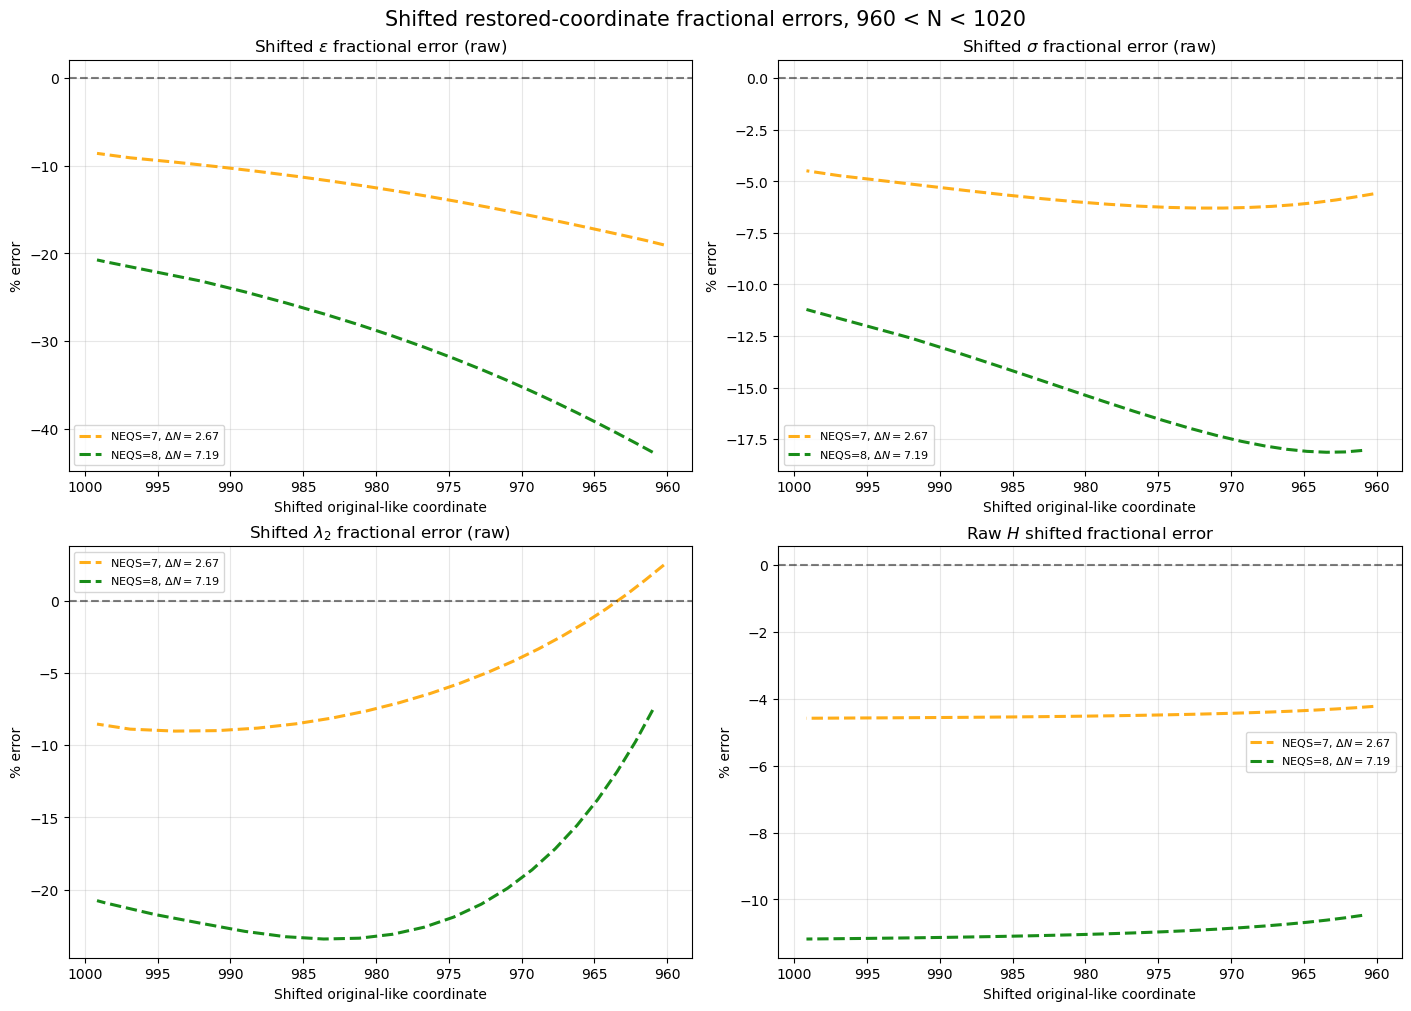

 NEQS   deltaN  normalize_SRPs  normalize_H  median_abs_frac_eps_pct  median_abs_frac_sigma_pct  median_abs_frac_lam2_pct  median_abs_frac_H_pct  max_abs_frac_eps_pct  max_abs_frac_sigma_pct  max_abs_frac_lam2_pct  max_abs_frac_H_pct
    7 2.673499           False        False                13.815191                   5.947168                  6.065595               4.487054             19.020029                6.295916               9.015100            4.582269
    8 7.186161           False        False                31.325557                  16.366723                 20.959563              10.982881             42.679016               18.134802              23.420255           11.182326


In [91]:
def plot_shifted_restored_fractional_errors_base_neqs6_8(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
    normalize_H=True,
    normalize_SRPs=False,
    N_norm_ref=60.0,
    N_window_min=960.0,
    N_window_max=1000.0,
    denom_floor=1e-30,
    save_name=None,
):

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    def load_path_N_3srp_H(NEQS, param_name, value):
        data = load_path_data(NEQS, param_name, value)

        N = data[:, NEQS]
        eps = data[:, 2]
        sigma = data[:, 3]
        lam2 = data[:, 4]
        H = data[:, 1]

        N, eps = prepare_increasing(N, eps)
        _, sigma = prepare_increasing(data[:, NEQS], sigma)
        _, lam2 = prepare_increasing(data[:, NEQS], lam2)
        _, H = prepare_increasing(data[:, NEQS], H)

        return N, eps, sigma, lam2, H

    def safe_frac(model, ref):
        return (model - ref) / np.where(
            np.abs(ref) > denom_floor,
            ref,
            np.nan,
        )

    # Reference
    ref_row = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS
    ].iloc[0]

    ref_original_N_end = ref_row["original_N_end"]
    ref_param, ref_value = base_params[ref_NEQS]

    N_ref_recon, eps_ref, sigma_ref, lam2_ref, H_ref = load_path_N_3srp_H(
        ref_NEQS, ref_param, ref_value
    )

    # Reference SRPs: raw or normalized
    if normalize_SRPs:
        N_ref_eps, eps_ref_use, _ = normalize_curve_at_Nref(
            N_ref_recon, eps_ref, N_ref=N_norm_ref
        )
        N_ref_sig, sigma_ref_use, _ = normalize_curve_at_Nref(
            N_ref_recon, sigma_ref, N_ref=N_norm_ref
        )
        N_ref_lam2, lam2_ref_use, _ = normalize_curve_at_Nref(
            N_ref_recon, lam2_ref, N_ref=N_norm_ref
        )

        srp_label = rf"normalized at $N={N_norm_ref}$"

    else:
        N_ref_eps, eps_ref_use = prepare_increasing(N_ref_recon, eps_ref)
        N_ref_sig, sigma_ref_use = prepare_increasing(N_ref_recon, sigma_ref)
        N_ref_lam2, lam2_ref_use = prepare_increasing(N_ref_recon, lam2_ref)

        srp_label = "raw"

    N_ref_eps_orig = ref_original_N_end + N_ref_eps
    N_ref_sig_orig = ref_original_N_end + N_ref_sig
    N_ref_lam2_orig = ref_original_N_end + N_ref_lam2

    # Reference H: raw or normalized
    if normalize_H:
        N_ref_H, H_ref_use, _ = normalize_curve_at_Nref(
            N_ref_recon, H_ref, N_ref=N_norm_ref
        )
        H_title = rf"$H/H({N_norm_ref})$ shifted fractional error"
    else:
        N_ref_H, H_ref_use = prepare_increasing(N_ref_recon, H_ref)
        H_title = r"Raw $H$ shifted fractional error"

    N_ref_H_orig = ref_original_N_end + N_ref_H

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 10),
        constrained_layout=True,
    )

    ax_eps, ax_sig = axes[0]
    ax_lam2, ax_H = axes[1]

    rows = []

    for NEQS, (param_name, value) in base_params.items():

        if NEQS == ref_NEQS:
            continue

        row = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS
        ].iloc[0]

        original_N_end = row["original_N_end"]
        deltaN = original_N_end - ref_original_N_end

        N_recon, eps, sigma, lam2, H = load_path_N_3srp_H(
            NEQS, param_name, value
        )

        # Model SRPs: raw or normalized
        if normalize_SRPs:
            N_eps, eps_use, _ = normalize_curve_at_Nref(
                N_recon, eps, N_ref=N_norm_ref
            )
            N_sig, sigma_use, _ = normalize_curve_at_Nref(
                N_recon, sigma, N_ref=N_norm_ref
            )
            N_lam2, lam2_use, _ = normalize_curve_at_Nref(
                N_recon, lam2, N_ref=N_norm_ref
            )
        else:
            N_eps, eps_use = prepare_increasing(N_recon, eps)
            N_sig, sigma_use = prepare_increasing(N_recon, sigma)
            N_lam2, lam2_use = prepare_increasing(N_recon, lam2)

        # Restore, then shift by deltaN
        N_eps_shifted = original_N_end + N_eps - deltaN
        N_sig_shifted = original_N_end + N_sig - deltaN
        N_lam2_shifted = original_N_end + N_lam2 - deltaN

        # Model H: raw or normalized
        if normalize_H:
            N_H, H_use, _ = normalize_curve_at_Nref(
                N_recon, H, N_ref=N_norm_ref
            )
        else:
            N_H, H_use = prepare_increasing(N_recon, H)

        N_H_shifted = original_N_end + N_H - deltaN

        # Interpolate reference onto shifted model grids
        eps_ref_interp = np.interp(
            N_eps_shifted, N_ref_eps_orig, eps_ref_use
        )
        sigma_ref_interp = np.interp(
            N_sig_shifted, N_ref_sig_orig, sigma_ref_use
        )
        lam2_ref_interp = np.interp(
            N_lam2_shifted, N_ref_lam2_orig, lam2_ref_use
        )
        H_ref_interp = np.interp(
            N_H_shifted, N_ref_H_orig, H_ref_use
        )

        # Fractional errors
        frac_eps = safe_frac(eps_use, eps_ref_interp)
        frac_sigma = safe_frac(sigma_use, sigma_ref_interp)
        frac_lam2 = safe_frac(lam2_use, lam2_ref_interp)
        frac_H = safe_frac(H_use, H_ref_interp)

        # Window masks
        eps_mask = (
            (N_eps_shifted >= N_window_min) &
            (N_eps_shifted <= N_window_max)
        )
        sig_mask = (
            (N_sig_shifted >= N_window_min) &
            (N_sig_shifted <= N_window_max)
        )
        lam2_mask = (
            (N_lam2_shifted >= N_window_min) &
            (N_lam2_shifted <= N_window_max)
        )
        H_mask = (
            (N_H_shifted >= N_window_min) &
            (N_H_shifted <= N_window_max)
        )

        N_eps_win = N_eps_shifted[eps_mask]
        N_sig_win = N_sig_shifted[sig_mask]
        N_lam2_win = N_lam2_shifted[lam2_mask]
        N_H_win = N_H_shifted[H_mask]

        frac_eps_win = frac_eps[eps_mask]
        frac_sigma_win = frac_sigma[sig_mask]
        frac_lam2_win = frac_lam2[lam2_mask]
        frac_H_win = frac_H[H_mask]

        label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"

        # Plot in percent
        ax_eps.plot(
            N_eps_win, 100 * frac_eps_win,
            color=colors.get(NEQS),
            lw=2.2,
            alpha=0.9,
            linestyle="--",
            label=label,
        )

        ax_sig.plot(
            N_sig_win, 100 * frac_sigma_win,
            color=colors.get(NEQS),
            lw=2.2,
            alpha=0.9,
            linestyle="--",
            label=label,
        )

        ax_lam2.plot(
            N_lam2_win, 100 * frac_lam2_win,
            color=colors.get(NEQS),
            lw=2.2,
            alpha=0.9,
            linestyle="--",
            label=label,
        )

        ax_H.plot(
            N_H_win, 100 * frac_H_win,
            color=colors.get(NEQS),
            lw=2.2,
            alpha=0.9,
            linestyle="--",
            label=label,
        )

        rows.append({
            "NEQS": NEQS,
            "deltaN": deltaN,
            "normalize_SRPs": normalize_SRPs,
            "normalize_H": normalize_H,

            "median_abs_frac_eps_pct":
                100 * np.nanmedian(np.abs(frac_eps_win)),
            "median_abs_frac_sigma_pct":
                100 * np.nanmedian(np.abs(frac_sigma_win)),
            "median_abs_frac_lam2_pct":
                100 * np.nanmedian(np.abs(frac_lam2_win)),
            "median_abs_frac_H_pct":
                100 * np.nanmedian(np.abs(frac_H_win)),

            "max_abs_frac_eps_pct":
                100 * np.nanmax(np.abs(frac_eps_win)),
            "max_abs_frac_sigma_pct":
                100 * np.nanmax(np.abs(frac_sigma_win)),
            "max_abs_frac_lam2_pct":
                100 * np.nanmax(np.abs(frac_lam2_win)),
            "max_abs_frac_H_pct":
                100 * np.nanmax(np.abs(frac_H_win)),
        })

        print(
            f"NEQS={NEQS}: "
            f"deltaN={deltaN:.4f}, "
            f"SRPs={srp_label}, "
            f"median |frac eps|="
            f"{100*np.nanmedian(np.abs(frac_eps_win)):.3e}%, "
            f"median |frac H|="
            f"{100*np.nanmedian(np.abs(frac_H_win)):.3e}%"
        )

    ax_eps.set_title(rf"Shifted $\epsilon$ fractional error ({srp_label})")
    ax_sig.set_title(rf"Shifted $\sigma$ fractional error ({srp_label})")
    ax_lam2.set_title(rf"Shifted $\lambda_2$ fractional error ({srp_label})")
    ax_H.set_title(H_title)

    for ax in axes.ravel():
        ax.axhline(0.0, color="black", ls="--", alpha=0.5)
        ax.set_xlabel(r"Shifted original-like coordinate")
        ax.set_ylabel(r"% error")
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    fig.suptitle(
        rf"Shifted restored-coordinate fractional errors, "
        rf"{N_window_min:.0f} < N < {N_window_max:.0f}",
        fontsize=15,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

    return pd.DataFrame(rows)



#raw only
# df_raw_srp = plot_shifted_restored_fractional_errors_base_neqs6_8(
#     base_path_root=base_path_root,
#     base_summary_df=base_summary_df,
#     normalize_H=True,
#     normalize_SRPs=False,
#     N_window_min=960,
#     N_window_max=1000,
#     save_name="shifted_frac_raw_srp_normH.png",
# )

# print(df_raw_srp.to_string(index=False))


#shape only comparison
df_norm_srp = plot_shifted_restored_fractional_errors_base_neqs6_8(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    normalize_H=False,
    normalize_SRPs=False,
    N_window_min=960,
    N_window_max=1020,
    save_name="shifted_frac_norm_srp_normH.png",
)

print(df_norm_srp.to_string(index=False))

In [92]:
pretty_df = df_norm_srp.copy()

# nicer column names
pretty_df = pretty_df.rename(columns={

    "deltaN":
        r"$\Delta N$",

    "median_abs_frac_eps_pct":
        r"median $|\delta \epsilon/\epsilon|$ [%]",

    "median_abs_frac_sigma_pct":
        r"median $|\delta \sigma/\sigma|$ [%]",

    "median_abs_frac_lam2_pct":
        r"median $|\delta \lambda_2/\lambda_2|$ [%]",

    "median_abs_frac_H_pct":
        r"median $|\delta H/H|$ [%]",

    "max_abs_frac_eps_pct":
        r"max $|\delta \epsilon/\epsilon|$ [%]",

    "max_abs_frac_sigma_pct":
        r"max $|\delta \sigma/\sigma|$ [%]",

    "max_abs_frac_lam2_pct":
        r"max $|\delta \lambda_2/\lambda_2|$ [%]",

    "max_abs_frac_H_pct":
        r"max $|\delta H/H|$ [%]",
})

# round everything cleanly
pretty_df = pretty_df.round({

    r"$\Delta N$": 3,

    r"median $|\delta \epsilon/\epsilon|$ [%]": 3,
    r"median $|\delta \sigma/\sigma|$ [%]": 3,
    r"median $|\delta \lambda_2/\lambda_2|$ [%]": 3,
    r"median $|\delta H/H|$ [%]": 3,

    r"max $|\delta \epsilon/\epsilon|$ [%]": 3,
    r"max $|\delta \sigma/\sigma|$ [%]": 3,
    r"max $|\delta \lambda_2/\lambda_2|$ [%]": 3,
    r"max $|\delta H/H|$ [%]": 3,
})

display(pretty_df)

,NEQS,$\Delta N$,normalize_SRPs,normalize_H,median $|\delta \epsilon/\epsilon|$ [%],median $|\delta \sigma/\sigma|$ [%],median $|\delta \lambda_2/\lambda_2|$ [%],median $|\delta H/H|$ [%],max $|\delta \epsilon/\epsilon|$ [%],max $|\delta \sigma/\sigma|$ [%],max $|\delta \lambda_2/\lambda_2|$ [%],max $|\delta H/H|$ [%]
0,7,2.673,False,False,13.815,5.947,6.066,4.487,19.020,6.296,9.015,4.582
1,8,7.186,False,False,31.326,16.367,20.960,10.983,42.679,18.135,23.420,11.182


So accounting for deltaN and normalizing, H(N) shows that trajectory is quite similar. HOWEVER, it also shows that the slow-roll parameters have a bit more difference to them where they have similar shape but are no identical. Without accounting for amplitude shifts we see significantly more shifting. Remember the whole reason for doing this deltaN busines was to determine if that is the reason we see an offset in the power spectra. 

In [ ]:
## POWER SPECTRA

In [102]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.gridspec import GridSpec

SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}


def plot_big_normalized_scan_summary(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    ref_floor_spec=1e-30,
    ref_floor_bg=1e-20,
    frac_floor=1e-100,
    H_scale=1.0,
    V_scale=1.0,
    cmap_name="plasma",
    save_name=None,
    suptitle=None,
    show=True,
):
    """
    Build one large figure containing:

      Row 1: normalized P_s(k), normalized P_t(k)
      Row 2: fractional error in normalized P_s(k), fractional error in normalized P_t(k)
      Row 3: normalized H(N), fractional error in normalized H(N)
      Row 4: normalized V(phi), fractional error in normalized V(phi)
      Row 5: summary stats table for Pt and H

    Definitions
    -----------
    Spectra are shape-normalized:
        P_s_norm(k) = P_s(k) / P_s(k_ref)
        P_t_norm(k) = P_t(k) / P_t(k_ref)

    Background curves are normalized at N_ref:
        H_norm(N)   = H(N) / H(N_ref)
        V_norm(phi) = V(phi) / V(N_ref)

    Error curves are fractional differences relative to the chosen base model:
        (curve - curve_base) / curve_base
    """

    def get_scan_info(neqs):
        if neqs not in SCAN_INFO:
            raise ValueError(f"Unsupported NEQS = {neqs}")
        return SCAN_INFO[neqs]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float
        )

    def prepare_increasing(x, y):
        """
        Accept monotonic x only.
        If fully decreasing, reverse x and y together.
        Refuse non-monotonic arrays.
        """
        x = np.asarray(x)
        y = np.asarray(y)

        if x.shape != y.shape:
            raise ValueError("x and y must have the same shape")

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError(
                "x is not monotonic; refusing to reorder because that could distort physics."
            )

    def normalize_curve_at_ref(x, y, x_ref, ref_floor):
        x_use, y_use = prepare_increasing(x, y)

        if x_ref < np.min(x_use) or x_ref > np.max(x_use):
            raise ValueError(
                f"Reference x_ref={x_ref} outside range [{np.min(x_use)}, {np.max(x_use)}]"
            )

        y_ref = np.interp(x_ref, x_use, y_use)

        if np.abs(y_ref) < ref_floor:
            raise ValueError(
                f"Reference value too small for normalization at x_ref={x_ref}: {y_ref:.3e}"
            )

        return x_use, y_use / y_ref, y_ref

    def fractional_difference_on_common_x(x_base, y_base, x_cmp, y_cmp, floor=1e-100):
        """
        Evaluate:
            (y_cmp_interp - y_base) / y_base
        on the overlap, using the base grid.
        """
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        denom = np.where(np.abs(y_base_use) > floor, y_base_use, np.nan)
        frac = (y_cmp_interp - y_base_use) / denom
        return x_use, frac

    def load_specs(value):
        val_str = f"{value:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_s = os.path.join(folder, f"spec_s_neqs{NEQS}.dat")
        file_t = os.path.join(folder, f"spec_t_neqs{NEQS}.dat")

        data_s = np.loadtxt(file_s)
        data_t = np.loadtxt(file_t)

        k_s = data_s[:, 0]
        Ps = np.abs(data_s[:, 1])

        k_t = data_t[:, 0]
        Pt = np.abs(data_t[:, 1])

        return k_s, Ps, k_t, Pt

    def load_path(value):
        val_str = f"{value:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{scan_name}_{val_str}.dat"
        )

        return pd.read_csv(file_path, sep=r"\s+", header=None).values



    def extract_cols(path_data):
        """
        Assumed column convention:
            phi = 0
            H   = 1
            N   = NEQS
            V   = NEQS + 1
        """
        phi = path_data[:, 0]
        H = path_data[:, 1]
        N = path_data[:, NEQS]
        V = path_data[:, NEQS + 1]
        return phi, H, N, V

    def get_normalized_H_vs_N(path_data):
        _, H, N, _ = extract_cols(path_data)
        N_use, H_norm, H_ref = normalize_curve_at_ref(N, H, N_ref, ref_floor_bg)
        return N_use, H_norm, H_ref

#     def get_normalized_V_vs_phi(path_data):
#         phi_raw, _, N_raw, V_raw = extract_cols(path_data)

#         # First use monotonic N ordering for physical trajectory order
#         N_use, phi_use = prepare_increasing(N_raw, phi_raw)
#         _, V_use = prepare_increasing(N_raw, V_raw)

#         if N_ref < np.min(N_use) or N_ref > np.max(N_use):
#             raise ValueError(
#                 f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
#             )

#         V_ref = np.interp(N_ref, N_use, V_use)

#         if np.abs(V_ref) < ref_floor_bg:
#             raise ValueError(
#                 f"Reference V(N_ref) too small at N_ref={N_ref}: {V_ref:.3e}"
#             )

#         V_norm = V_use / V_ref

    def get_normalized_V_vs_phi(path_data):
        phi_raw, _, N_raw, V_raw = extract_cols(path_data)

        N_use, phi_use = prepare_increasing(N_raw, phi_raw)
        _, V_use = prepare_increasing(N_raw, V_raw)


        if N_ref < np.min(N_use) or N_ref > np.max(N_use):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        V_ref = np.interp(N_ref, N_use, V_use)

        if np.abs(V_ref) < ref_floor_bg:
            raise ValueError(
                f"Reference V(N_ref) too small at N_ref={N_ref}: {V_ref:.3e}"
            )
        V_norm = V_use / V_ref

#         phi_plot, V_plot = prepare_increasing(phi_use, V_norm)
#         return phi_plot, V_plot, V_ref



        # Then prepare phi-space version
#         phi_plot, V_plot = prepare_increasing(phi_use, V_norm)
        
        phi_plot = phi_use
        V_plot = V_norm
        return phi_plot, V_plot, V_ref
   

    def setup_colorbar(fig, axes, lam_vals, scan_symbol, cmap_name="plasma"):
#         cmap = cm.get_cmap(cmap_name)
        import matplotlib as mpl
        cmap = mpl.colormaps[cmap_name]
        norm = mcolors.Normalize(vmin=np.min(lam_vals), vmax=np.max(lam_vals))
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)

        cbar = fig.colorbar(
            sm,
            ax=axes,
            orientation="vertical",
            fraction=0.015,
            pad=0.02
        )
        cbar.set_label(rf"${scan_symbol}$", fontsize=12)
        return cmap, norm

    # ---------------- setup ----------------
    scan_name, scan_symbol = get_scan_info(NEQS)
    lamX_numeric = sanitize_lam_values(lamX_values)

    # ---------------- base model ----------------
    try:
        k_s_base, Ps_base, k_t_base, Pt_base = load_specs(baseX)
        path_base = load_path(baseX)
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Base model files not found for {scan_name} = {baseX:.5e}"
        ) from e

    k_s_base, Ps_base_norm, _ = normalize_curve_at_ref(
        k_s_base, Ps_base, k_ref, ref_floor_spec
    )
    k_t_base, Pt_base_norm, _ = normalize_curve_at_ref(
        k_t_base, Pt_base, k_ref, ref_floor_spec
    )

    N_H_base, H_base_norm, _ = get_normalized_H_vs_N(path_base)
    phi_V_base, V_base_norm, _ = get_normalized_V_vs_phi(path_base)

    # ---------------- figure ----------------
    fig = plt.figure(figsize=(18, 22), constrained_layout=True)
    gs = GridSpec(
        5, 2,
        figure=fig,
        height_ratios=[1.0, 1.0, 1.0, 1.0, 1.1]
    )

    ax_ps       = fig.add_subplot(gs[0, 0])
    ax_pt       = fig.add_subplot(gs[0, 1])
    ax_ps_err   = fig.add_subplot(gs[1, 0])
    ax_pt_err   = fig.add_subplot(gs[1, 1])
    ax_h        = fig.add_subplot(gs[2, 0])
    ax_h_err    = fig.add_subplot(gs[2, 1])
    ax_vphi     = fig.add_subplot(gs[3, 0])
    ax_vphi_err = fig.add_subplot(gs[3, 1])
    ax_table    = fig.add_subplot(gs[4, :])
    ax_table.axis("off")

    plot_axes = [ax_ps, ax_pt, ax_ps_err, ax_pt_err, ax_h, ax_h_err, ax_vphi, ax_vphi_err]
    cmap, norm = setup_colorbar(fig, plot_axes, lamX_numeric, scan_symbol, cmap_name=cmap_name)

    # ---------------- scan loop ----------------
    stats_rows = []

    for lamX in lamX_numeric:
        try:
            k_s, Ps, k_t, Pt = load_specs(lamX)
            path_data = load_path(lamX)

            # normalize spectra
            k_s_use, Ps_norm, _ = normalize_curve_at_ref(
                k_s, Ps, k_ref, ref_floor_spec
            )
            k_t_use, Pt_norm, _ = normalize_curve_at_ref(
                k_t, Pt, k_ref, ref_floor_spec
            )

            # normalize background
            N_H, H_norm, _ = get_normalized_H_vs_N(path_data)
            phi_V, V_norm, _ = get_normalized_V_vs_phi(path_data)

            color = cmap(norm(lamX))

            # fractional differences relative to base
            k_ps_err, frac_ps = fractional_difference_on_common_x(
                k_s_base, Ps_base_norm, k_s_use, Ps_norm, floor=frac_floor
            )
            k_pt_err, frac_pt = fractional_difference_on_common_x(
                k_t_base, Pt_base_norm, k_t_use, Pt_norm, floor=frac_floor
            )
            N_h_err, frac_h = fractional_difference_on_common_x(
                N_H_base, H_base_norm, N_H, H_norm, floor=frac_floor
            )
            phi_v_err, frac_v = fractional_difference_on_common_x(
                phi_V_base, V_base_norm, phi_V, V_norm, floor=frac_floor
            )

            # top/background plots
#             ax_ps.plot(k_s_use, Ps_norm, color=color, lw=1.6, alpha=0.9)
            k_max_scalar = 10.0
            mask_k = k_s_use <= k_max_scalar

            ax_ps.plot(
                k_s_use[mask_k],
                Ps_norm[mask_k],
                color=color,
                lw=1.6,
                alpha=0.9
            )
            ax_pt.plot(k_t_use, Pt_norm, color=color, lw=1.6, alpha=0.9)
            ax_h.plot(N_H, H_scale * H_norm, color=color, lw=1.6, alpha=0.9)
            ax_vphi.plot(phi_V, V_scale * V_norm, color=color, lw=1.6, alpha=0.9)

            # error plots
#             ax_ps_err.plot(k_ps_err, frac_ps, color=color, lw=1.6, alpha=0.9)
            mask_k_err = k_ps_err <= k_max_scalar

            ax_ps_err.plot(
                k_ps_err[mask_k_err],
                frac_ps[mask_k_err],
                color=color,
                lw=1.6,
                alpha=0.9
            )
            ax_pt_err.plot(k_pt_err, frac_pt, color=color, lw=1.6, alpha=0.9)
            ax_h_err.plot(N_h_err, frac_h, color=color, lw=1.6, alpha=0.9)
            ax_vphi_err.plot(phi_v_err, frac_v, color=color, lw=1.6, alpha=0.9)

            # summary table values
            mask_ps_stats = k_ps_err <= k_max_scalar
            frac_ps_use = frac_ps[mask_ps_stats]

            stats_rows.append({
                "lamX": lamX,

                # tensor (%)
                "mean_dPt_pct": 100 * np.nanmean(frac_pt),
                "max_dPt_pct": 100 * np.nanmax(np.abs(frac_pt)),

                # scalar (%), restricted k
                "mean_dPs_pct": 100 * np.nanmean(frac_ps_use),
                "max_dPs_pct": 100 * np.nanmax(np.abs(frac_ps_use)),

                # background (%)
                "mean_dH_pct": 100 * np.nanmean(frac_h),
                "max_dH_pct": 100 * np.nanmax(np.abs(frac_h)),

                "mean_dV_pct": 100 * np.nanmean(frac_v),
                "max_dV_pct": 100 * np.nanmax(np.abs(frac_v)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name} = {lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name} = {lamX:.5e}: {e}")

    stats_df = pd.DataFrame(stats_rows)

    # ---------------- titles ----------------
    ax_ps.set_title(
        rf"Normalized scalar spectrum: $\mathcal{{P}}_\mathcal{{R}}(k)/\mathcal{{P}}_\mathcal{{R}}({k_ref})$"
    )
    ax_pt.set_title(
        rf"Normalized tensor spectrum: $\mathcal{{P}}_t(k)/\mathcal{{P}}_t({k_ref})$"
    )

    ax_ps_err.set_title(r"Fractional error in normalized $\mathcal{P}_{\mathcal{R}}(k)$")
    ax_pt_err.set_title(r"Fractional error in normalized $\mathcal{P}_t(k)$")

    ax_h.set_title(rf"Normalized Hubble parameter: $H(N)/H({N_ref})$")
    ax_h_err.set_title(r"Fractional error in normalized $H(N)$")

    ax_vphi.set_title(rf"Normalized potential: $V(\phi)/V(N={N_ref})$")
    ax_vphi_err.set_title(r"Fractional error in normalized $V(\phi)$")

    # ---------------- y labels ----------------
    ax_ps.set_ylabel(r"$\mathcal{P}_{\mathcal{R},\mathrm{norm}}$")
    ax_pt.set_ylabel(r"$\mathcal{P}_{t,\mathrm{norm}}$")

    ax_ps_err.set_ylabel(
        r"$\left(\mathcal{P}_{\mathcal{R},\mathrm{norm}}-\mathcal{P}_{\mathcal{R},\mathrm{base}}\right)/\mathcal{P}_{\mathcal{R},\mathrm{base}}$"
    )
    ax_pt_err.set_ylabel(
        r"$\left(\mathcal{P}_{t,\mathrm{norm}}-\mathcal{P}_{t,\mathrm{base}}\right)/\mathcal{P}_{t,\mathrm{base}}$"
    )

    if H_scale == 1.0:
      
        ax_h.set_ylabel(r"$H/H(N_{\mathrm{ref}})$")
    else:
#         ax_h.set_ylabel(rf"${H_scale:.0e}\,H/H(N_{{\mathrm{{ref}}}})$")
        ax_h.set_ylabel(rf"$10^{6}H/H(N_{{\mathrm{{ref}}}})$")


    ax_h_err.set_ylabel(
        r"$\left(H_{\mathrm{norm}}-H_{\mathrm{base}}\right)/H_{\mathrm{base}}$"
    )

    if V_scale == 1.0:
        ax_vphi.set_ylabel(r"$V/V(N_{\mathrm{ref}})$")
    else:
#         ax_vphi.set_ylabel(rf"${V_scale:.0e}\,V/V(N_{{\mathrm{{ref}}}})$")
        ax_vphi.set_ylabel(rf"$10^{{13}}V/V(N_{{\mathrm{{ref}}}})$")


    ax_vphi_err.set_ylabel(
        r"$\left(V_{\mathrm{norm}}-V_{\mathrm{base}}\right)/V_{\mathrm{base}}$"
    )

    # ---------------- x labels ----------------
    ax_ps_err.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_pt_err.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_h.set_xlabel(r"$N$")
    ax_h_err.set_xlabel(r"$N$")
    ax_vphi.set_xlabel(r"$\phi$")
    ax_vphi_err.set_xlabel(r"$\phi$")

    # ---------------- styling ----------------
    # spectra: log x and log y
    for ax in [ax_ps, ax_pt]:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # spectra errors: log x only
    for ax in [ax_ps_err, ax_pt_err]:
        ax.set_xscale("log")
        ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # H plot: inverted x and log y
    ax_h.invert_xaxis()
#     ax_h.set_yscale("log")
    ax_h.grid(True, alpha=0.25)

    # H error: inverted x, linear y
    ax_h_err.invert_xaxis()
    ax_h_err.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax_h_err.grid(True, alpha=0.25)

    # V(phi) plot: inverted x and log y
#     ax_vphi.invert_xaxis()
#     ax_vphi.set_yscale("log")
    ax_vphi.grid(True, alpha=0.25)

    # V(phi) error: inverted x, linear y
#     ax_vphi_err.invert_xaxis()
    ax_vphi_err.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax_vphi_err.grid(True, alpha=0.25)
# ---------------- simple printed summary ----------------
    ax_table.set_visible(False)

    ax_table.set_visible(False)

    if not stats_df.empty:
        print("\n=== Summary Statistics (% difference from base) ===\n")

        display_df = stats_df.copy()

        for col in display_df.columns:
            if col == "lamX":
                display_df[col] = display_df[col].map(lambda x: f"{x:.2e}")
            else:
                display_df[col] = display_df[col].map(lambda x: f"{x:.3f}%")

        print(display_df.to_string(index=False))
    else:
        print("\nNo valid models loaded.\n")

    # ---------------- title / save ----------------
    if suptitle is None:
        suptitle = (
            rf"Normalized spectra and background summary for NEQS={NEQS} "
            rf"(${scan_symbol}$ scan, base = {baseX:.2e})"
        )
    fig.suptitle(suptitle, fontsize=17)

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_big_normalized_summary.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)
        
    phi, H, N, V = extract_cols(path_base)

    print("phi at max N:", phi[np.argmax(N)])
    print("phi at min N:", phi[np.argmin(N)])

    return stats_df


Summary for NEQS=6, parameter=lam3
Total models found: 40
Parameter range: -7.296e-05 to 9.679e-07


=== Summary Statistics (% difference from base) ===

     lamX mean_dPt_pct max_dPt_pct mean_dPs_pct max_dPs_pct mean_dH_pct max_dH_pct mean_dV_pct max_dV_pct
-7.30e-05       1.010%      4.483%       2.763%     12.433%     18.214%    43.855%     -9.522%    63.414%
-7.20e-05       1.007%      4.472%       2.659%     11.920%     18.138%    43.639%     -9.382%    62.537%
-7.08e-05       1.004%      4.457%       2.594%     11.306%     18.035%    43.350%     -9.196%    61.378%
-7.02e-05       1.002%      4.450%       2.543%     11.182%     17.986%    43.210%     -9.108%    60.824%
-6.92e-05       0.999%      4.438%       2.490%     10.718%     17.903%    42.976%     -8.962%    59.916%
-6.73e-05       0.993%      4.414%       2.209%      9.766%     17.740%    42.520%     -8.684%    58.175%
-6.71e-05       0.993%      4.411%       2.207%      9.661%     17.720%    42.462%     -8.650%    57.95

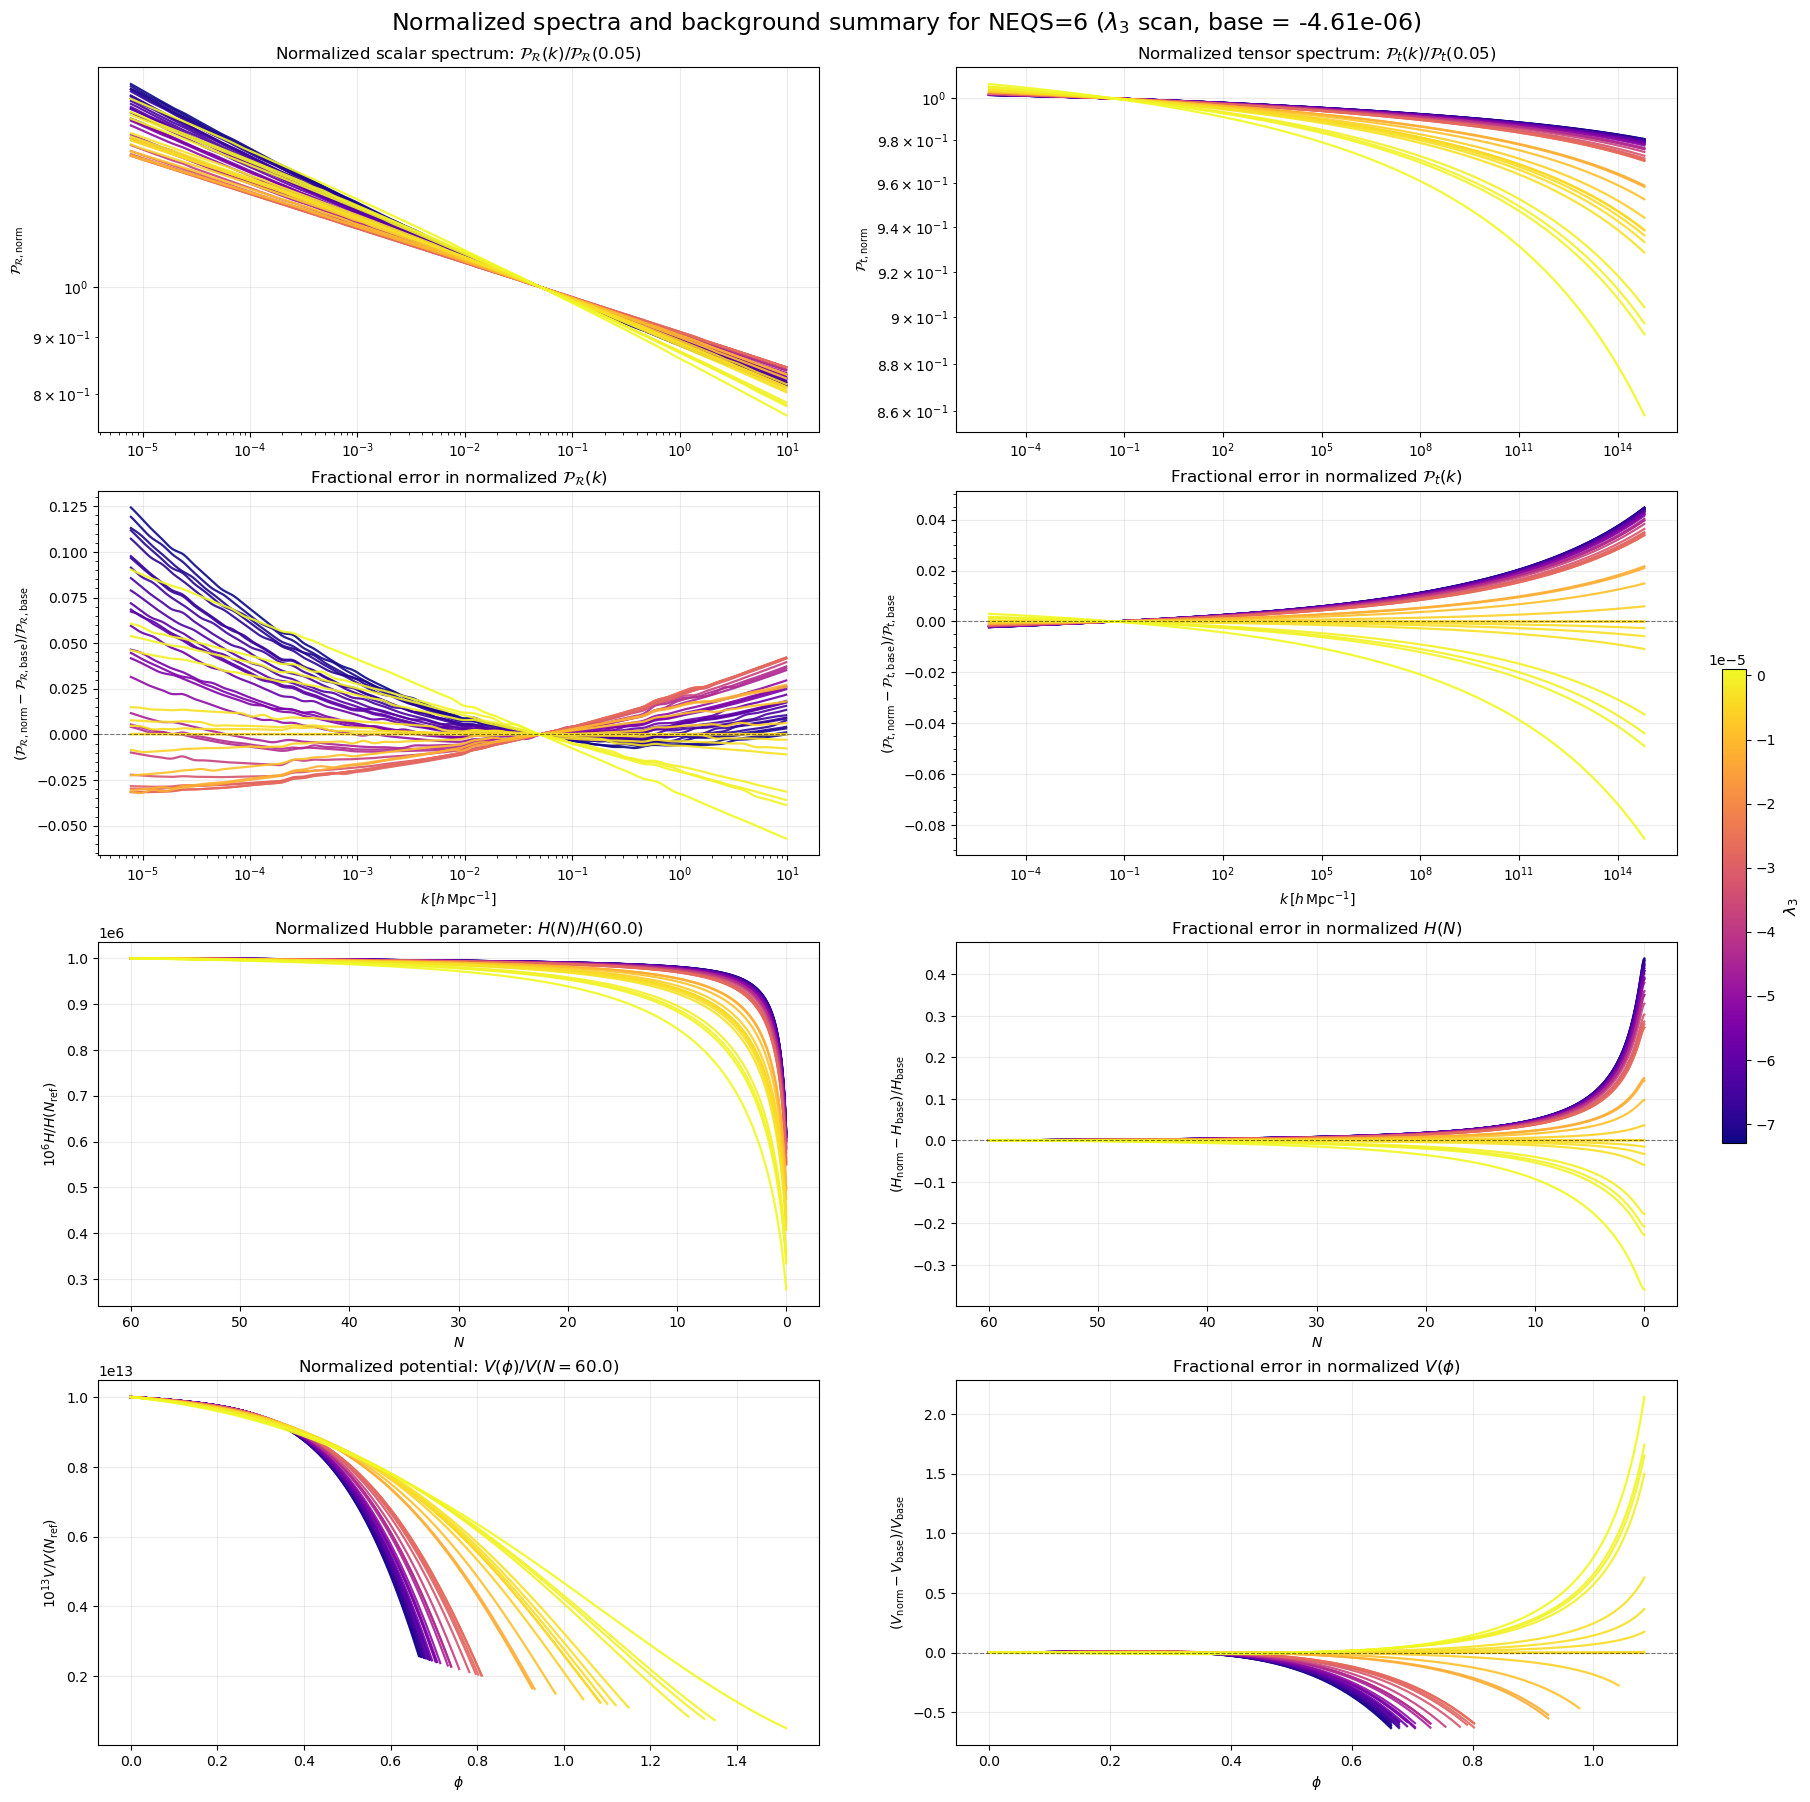

phi at max N: 0.0
phi at min N: 1.084339


In [104]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam3_values = get_param_values_from_dirs(6, "lam3", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,    
    V_scale=1e13,    
    save_name="expanded_neqs6_lam3_big_summary.png"
)

#print(stats_df)

In [106]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.970,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib import cm, colors as mcolors

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError("x grid is not monotonic")

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)
        y_ref = np.interp(x_ref, x, y)
        return x, y / y_ref

    def frac_on_base_grid(x_base, y_base, x_cmp, y_cmp, kmax=None):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        # ONLY upper cutoff
        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use
        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base, Ps_base_norm, k_s, Ps_norm, kmax=k_max_scalar
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base, Pt_base_norm, k_t, Pt_norm, kmax=None
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX", "ns", "delta_ns_from_base",
                "mean_dPs_pct", "max_dPs_pct",
                "mean_dPt_pct", "max_dPt_pct"
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check (in percentages) ===")
        print("All models:")
        print(
            stats_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )
        print("\nFiltered models:")
        print(
            kept_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = m["k_s"] <= k_max_scalar

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = k_s_base <= k_max_scalar

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.6)

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$")
    ax_pt.set_title(rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$")
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"% difference in $P_s$")
    ax_pt_err.set_ylabel(r"% difference in $P_t$")

    # ONLY upper cutoff behavior:
    ax_ps.set_xlim(np.min(k_s_base), k_max_scalar)
    ax_ps_err.set_xlim(np.min(k_ps_err), k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=8)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=16,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_{ns_min}_{ns_max}.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df


=== All models summary ===
Total loaded: 40
Base ns: 0.965678
Models in ns window [0.963, 0.969]: 16

=== Filtered models by ns cut ===
     lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-0.000045 0.963571           -0.002107      0.436794     3.516697      0.904871     4.034319
-0.000003 0.963964           -0.001714      0.262704     1.492713     -0.241361     1.079005
-0.000043 0.964421           -0.001257      0.340033     3.721994      0.891939     3.977717
-0.000043 0.964452           -0.001226      0.239506     3.623974      0.891439     3.975525
-0.000004 0.964739           -0.000939      0.067964     0.770892     -0.129312     0.577973
-0.000004 0.965248           -0.000430      0.095221     0.469127     -0.058371     0.260864
-0.000005 0.965667           -0.000011      0.001418     0.010161     -0.001542     0.006888
-0.000005 0.965678            0.000000      0.000000     0.000000      0.000000     0.000000
-0.000038 0.966154        

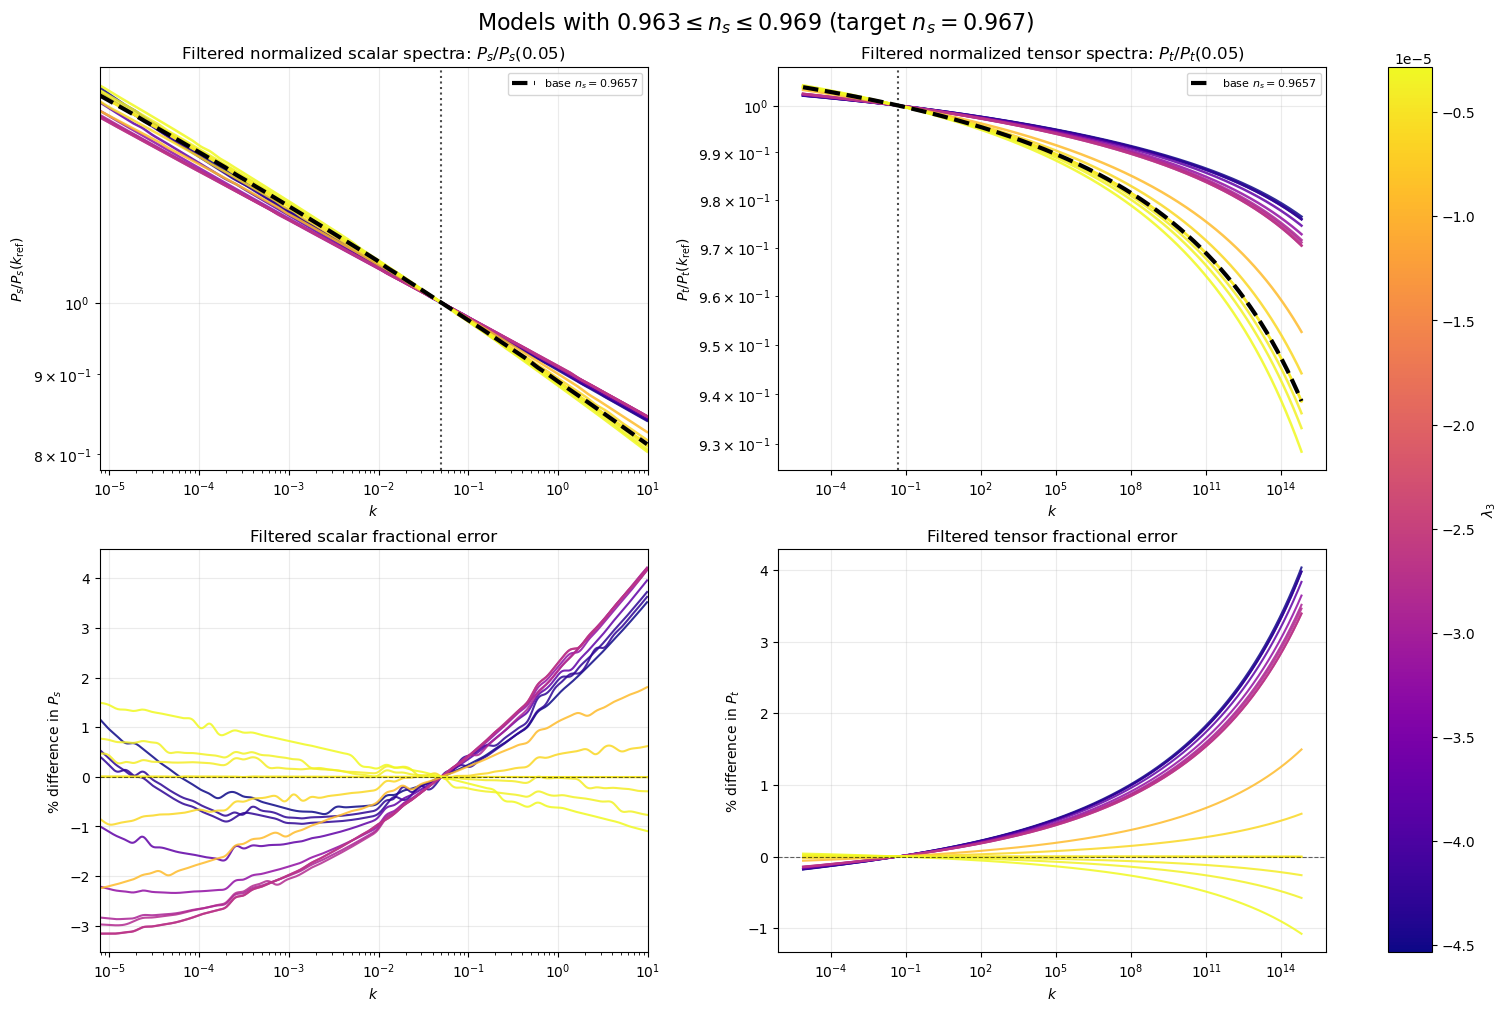

In [107]:
stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.963,
    ns_max=0.969,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    save_name="neqs6_lam3_filtered_ns_spectra.png"
)

Notice how there is a real spread in the scalar power spectrum.We want to test this out a bit to figure out why that is even there. The leading theory for us is that well, increasing the truncation order does not simply reproduce the identical model at the same e-fold location. Instead, it shifts the effective location of the trajectory in N, and that shift propagates into the observables, producing a higher ns, lower r, and measurable differences in the spectra!!! More professionally, higher-order slow-roll terms act primarily like an N-shift along a similar inflationary trajectory, with small residual changes to the dynamics. Bruh how do we quantify how much it moves? Like why that much?

Relative to NEQS=6, NEQS=7 is shifted by +2.67 e-folds and NEQS=8 by +7.19 e-folds in the original end-of-inflation coordinate.

Next step is to test that by adjusting NEQs 6-8 by their associated deltaN.

In [120]:
def test_k_shift_equivalence(
    base_path_root,
    base_params,
    base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
):

    def load_specs(NEQS, param, val):
        val_str = f"{val:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{param}_{val_str}")
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        k = s[:, 0]
        Ps = np.abs(s[:, 1])
        order = np.argsort(k)
        return k[order], Ps[order]
    
#load reference spectrum
    ref_param, ref_val = base_params[ref_NEQS]
    k_ref, Ps_ref = load_specs(ref_NEQS, ref_param, ref_val)
    Ps_ref = Ps_ref / np.interp(k_norm, k_ref, Ps_ref) #normalize her

    plt.figure(figsize=(7, 5))
    k_max_plot=10.0
    mask_ref = k_ref <= k_max_plot

    plt.loglog(k_ref[mask_ref], Ps_ref[mask_ref], lw=3, color="black", label=f"NEQS={ref_NEQS} reference",linestyle="--")

    ref_N_end = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS, "original_N_end"
    ].iloc[0]

    for NEQS, (param, val) in base_params.items():
        if NEQS == ref_NEQS:
            continue
            
        N_end = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS, "original_N_end"
        ].iloc[0]
        print("N_end:",N_end)

        deltaN = N_end - ref_N_end #this is physical difference in inflation duration
        print("deltaN:", deltaN)
        k, Ps = load_specs(NEQS, param, val)#k here is loaded k as is and move it by e^N
        
        k_shifted = k * np.exp(-deltaN) 
        #should tell us where the mode would have exited in the reference timeline
        # only shift the k-grid horizontally in log-space by deltaN.
# this tests whether the spectral differences are mostly due to an N-offset.
        Ps = Ps / np.interp(k_norm, k_shifted, Ps) #normalize shifted spectrum at same pivot
    
#so we compare all models at same physical scale after correcting for timing differences
       

        # For an N-shift, compare P_model(k * exp(-deltaN)) against reference.
        mask = k_shifted <= k_max_plot

        plt.loglog(
            k_shifted[mask],
            Ps[mask],
            lw=2,
            label=rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$",linestyle="--"
        )

    plt.axvline(k_norm, color="black", ls=":", alpha=0.6)
    plt.xlabel(r"shifted $k$")
    plt.ylabel(rf"$P_s/P_s(k={k_norm})$")
    plt.title(r"Testing whether base spectra differ by a $k$-shift")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

N_end: 941.8370708048872
deltaN: 2.673498532437179
N_end: 946.3497329290956
deltaN: 7.1861606566455976


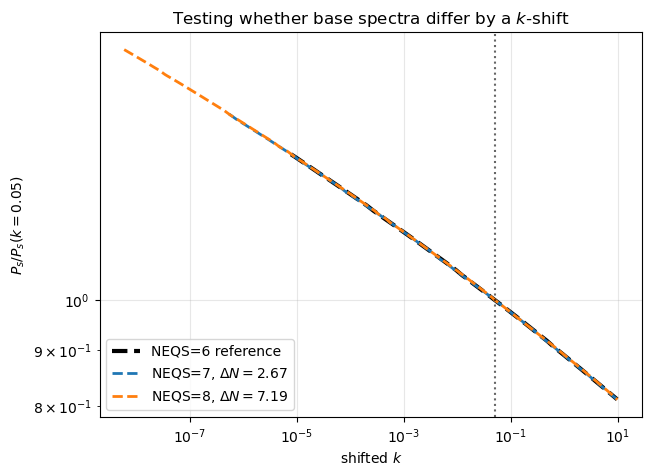

In [121]:
BASE_PARAMS = {
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
}

test_k_shift_equivalence(
    base_path_root=base_path_root,
    base_params=BASE_PARAMS,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
)

#I am doing this currently with -dN. It could be positive. 
# k ~ e^-N or ln k ~ -N where N is efolds from the end
#I am working with ln k ~ -deltaN, if deltaN positive k gets smaller



After correcting the horizontal k-location,  the spectra have the same shape around the same pivot.the spectral offset is largely a horizontal log-k shift induced by the N-offset.Let's apply this shift to the full set of data and see what is does.

In [122]:
def test_k_shift_equivalence_scalar_tensor(
    base_path_root,
    base_params,
    base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
    k_max_scalar=10.0,
):

    def load_specs(NEQS, param, val):
        val_str = f"{val:.10e}"
        folder = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param}_{val_str}"
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        k_s, Ps = prepare_increasing(k_s, Ps)
        k_t, Pt = prepare_increasing(k_t, Pt)

        return k_s, Ps, k_t, Pt

    # Reference spectra
    ref_param, ref_val = base_params[ref_NEQS]

    k_s_ref, Ps_ref, k_t_ref, Pt_ref = load_specs(
        ref_NEQS, ref_param, ref_val
    )

    Ps_ref = Ps_ref / np.interp(k_norm, k_s_ref, Ps_ref)
    Pt_ref = Pt_ref / np.interp(k_norm, k_t_ref, Pt_ref)

    ref_N_end = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS,
        "original_N_end"
    ].iloc[0]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 5),
        constrained_layout=True
    )

    ax_s, ax_t = axes

    # Reference scalar, cutoff at k_max_scalar
    mask_s_ref = k_s_ref <= k_max_scalar

    ax_s.loglog(
        k_s_ref[mask_s_ref],
        Ps_ref[mask_s_ref],
        lw=3,
        color="black",
        linestyle="--",
        label=f"NEQS={ref_NEQS} reference",
    )

    # Reference tensor, full k range
    ax_t.loglog(
        k_t_ref,
        Pt_ref,
        lw=3,
        color="black",
        linestyle="--",
        label=f"NEQS={ref_NEQS} reference",
    )

    for NEQS, (param, val) in base_params.items():

        if NEQS == ref_NEQS:
            continue

        N_end = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS,
            "original_N_end"
        ].iloc[0]

        deltaN = N_end - ref_N_end

        print(f"NEQS={NEQS}")
        print(f"  N_end  = {N_end:.6f}")
        print(f"  deltaN = {deltaN:.6f}")
        print(f"  exp(-deltaN) = {np.exp(-deltaN):.6e}")

        k_s, Ps, k_t, Pt = load_specs(NEQS, param, val)

        # In your convention a(N)=a_init exp(-N),
        # so the N-shift corresponds to k -> k exp(-deltaN).
        k_s_shifted = k_s * np.exp(-deltaN)
        k_t_shifted = k_t * np.exp(-deltaN)

        # Normalize AFTER shifting, at the same displayed pivot.
        Ps_shifted_norm = Ps / np.interp(k_norm, k_s_shifted, Ps)
        Pt_shifted_norm = Pt / np.interp(k_norm, k_t_shifted, Pt)

        label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"

        # Scalar: cutoff at k_max_scalar
        mask_s = k_s_shifted <= k_max_scalar

        ax_s.loglog(
            k_s_shifted[mask_s],
            Ps_shifted_norm[mask_s],
            lw=2,
            linestyle="--",
            color=colors.get(NEQS),
            label=label,
        )

        # Tensor: full shifted k range
        ax_t.loglog(
            k_t_shifted,
            Pt_shifted_norm,
            lw=2,
            linestyle="--",
            color=colors.get(NEQS),
            label=label,
        )

    for ax in axes:
        ax.axvline(k_norm, color="black", ls=":", alpha=0.6)
        ax.set_xlabel(r"shifted $k$")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    ax_s.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_t.set_ylabel(rf"$P_t/P_t(k={k_norm})$")

    ax_s.set_title(r"Scalar spectra after $k \to k e^{-\Delta N}$")
    ax_t.set_title(r"Tensor spectra after $k \to k e^{-\Delta N}$")

    fig.suptitle(
        r"Testing whether base spectra differ mainly by a $k$-shift",
        fontsize=15,
    )

    plt.show()

NEQS=7
  N_end  = 941.837071
  deltaN = 2.673499
  exp(-deltaN) = 6.901037e-02
NEQS=8
  N_end  = 946.349733
  deltaN = 7.186161
  exp(-deltaN) = 7.569899e-04


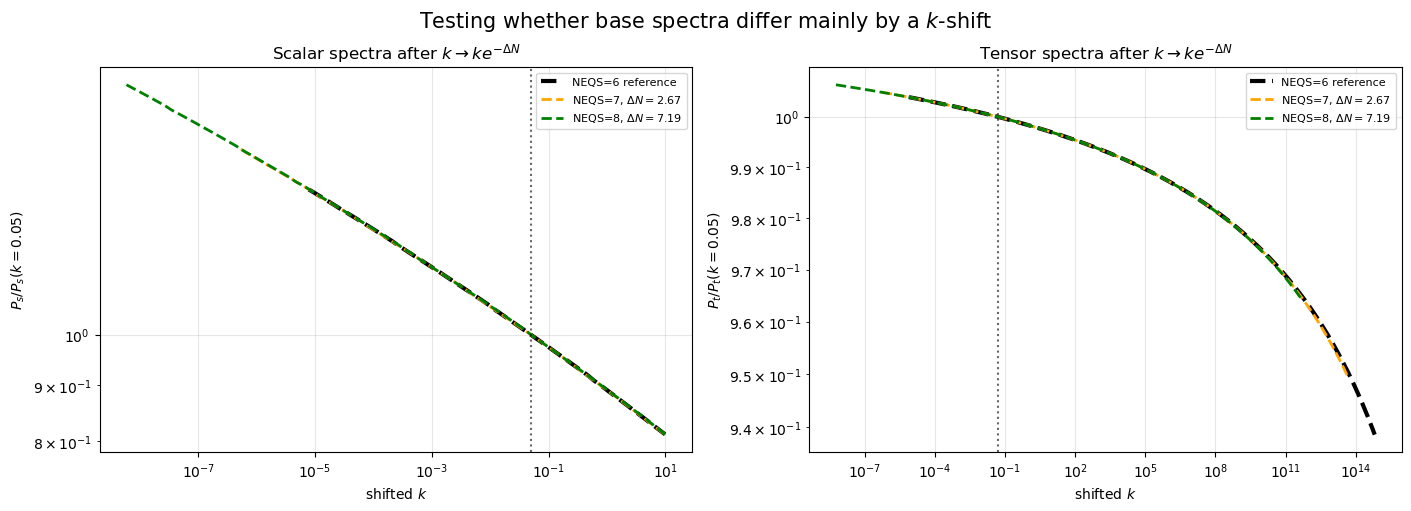

In [124]:
BASE_PARAMS = {
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
}

test_k_shift_equivalence_scalar_tensor(
    base_path_root=base_path_root,
    base_params=BASE_PARAMS,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
    k_max_scalar=10.0,
)

Let's apply a shift for all of these models we saw before maybe a bit later, I need to save their original N values in my run. For now we can examine the N shift when applied to the spectra log derivatives and see how much that helps.

In [127]:
def load_specs_local(NEQS, param_name, value):

    val_str = f"{value:.10e}"

    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    s = np.loadtxt(
        os.path.join(folder, f"spec_s_neqs{NEQS}.dat")
    )

    t = np.loadtxt(
        os.path.join(folder, f"spec_t_neqs{NEQS}.dat")
    )

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt

In [131]:
def plot_base_spectra_derivatives_bspline_2x2_kshifted(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
    apply_k_shift=True,
    k_min_plot=None,
    k_max_plot_s=10.0,
    k_max_plot_t=None,
    smoothing=0.0,
    save_name=None,
):

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    def prepare_log_spline(k, P, smoothing=0.0):
        k = np.asarray(k)
        P = np.asarray(P)

        mask = (k > 0) & (P > 0) & np.isfinite(k) & np.isfinite(P)
        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        x_unique = np.unique(x)
        y_unique = np.array([
            np.mean(y[x == xu]) for xu in x_unique
        ])

        spl = UnivariateSpline(x_unique, y_unique, s=smoothing, k=3)

        d1 = spl.derivative(1)(x_unique)
        d2 = spl.derivative(2)(x_unique)

        return np.exp(x_unique), d1, d2

    ref_N_end = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS,
        "original_N_end"
    ].iloc[0]

    fig, axes = plt.subplots(
        2, 2, figsize=(15, 10), constrained_layout=True
    )

    ax_d1Ps, ax_d1Pt = axes[0]
    ax_d2Ps, ax_d2Pt = axes[1]

    for NEQS, (param_name, value) in base_params.items():

        k_s, Ps, k_t, Pt = load_specs_local(NEQS, param_name, value)

        if apply_k_shift:
            N_end = base_summary_df.loc[
                base_summary_df["NEQS"] == NEQS,
                "original_N_end"
            ].iloc[0]

            deltaN = N_end - ref_N_end

            k_s = k_s * np.exp(-deltaN)
            k_t = k_t * np.exp(-deltaN)

        else:
            deltaN = 0.0

        k_s_use, d1Ps, d2Ps = prepare_log_spline(
            k_s, Ps, smoothing=smoothing
        )
        k_t_use, d1Pt, d2Pt = prepare_log_spline(
            k_t, Pt, smoothing=smoothing
        )

        mask_s = np.ones_like(k_s_use, dtype=bool)
        mask_t = np.ones_like(k_t_use, dtype=bool)

        if k_min_plot is not None:
            mask_s &= k_s_use >= k_min_plot
            mask_t &= k_t_use >= k_min_plot

        if k_max_plot_s is not None:
            mask_s &= k_s_use <= k_max_plot_s

        if k_max_plot_t is not None:
            mask_t &= k_t_use <= k_max_plot_t

        label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"
        color = colors.get(NEQS, None)

        ax_d1Ps.semilogx(
            k_s_use[mask_s],
            d1Ps[mask_s],
            color=color,
            lw=2.0,
            alpha=0.9,
            label=label,linestyle="--",
        )

        ax_d1Pt.semilogx(
            k_t_use[mask_t],
            d1Pt[mask_t],
            color=color,
            lw=2.0,
            alpha=0.9,
            label=label,linestyle="--",
        )

        ax_d2Ps.semilogx(
            k_s_use[mask_s],
            d2Ps[mask_s],
            color=color,
            lw=2.0,
            alpha=0.9,
            label=label,linestyle="--",
        )

        ax_d2Pt.semilogx(
            k_t_use[mask_t],
            d2Pt[mask_t],
            color=color,
            lw=2.0,
            alpha=0.9,
            label=label,linestyle="--",
        )

        print(
            f"NEQS={NEQS}: "
            f"deltaN={deltaN:.4f}, "
            f"exp(-deltaN)={np.exp(-deltaN):.4e}, "
            f"k_s shifted range=({k_s_use.min():.3e}, {k_s_use.max():.3e}), "
            f"k_t shifted range=({k_t_use.min():.3e}, {k_t_use.max():.3e})"
        )

    shift_label = (
        r"with $k \to k e^{-\Delta N}$"
        if apply_k_shift
        else "without $k$ shift"
    )

    ax_d1Ps.set_title(rf"Scalar first derivative, {shift_label}")
    ax_d1Pt.set_title(rf"Tensor first derivative, {shift_label}")
    ax_d2Ps.set_title(rf"Scalar second derivative, {shift_label}")
    ax_d2Pt.set_title(rf"Tensor second derivative, {shift_label}")

    ax_d1Ps.set_ylabel(r"$d\ln P_s / d\ln k$")
    ax_d1Pt.set_ylabel(r"$d\ln P_t / d\ln k$")
    ax_d2Ps.set_ylabel(r"$d^2\ln P_s / d(\ln k)^2$")
    ax_d2Pt.set_ylabel(r"$d^2\ln P_t / d(\ln k)^2$")

    for ax in axes.ravel():
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_xlabel(r"shifted $k$")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)

    fig.suptitle(
        rf"B-spline spectral derivatives: NEQS 6--8, {shift_label}",
        fontsize=16,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()
    

NEQS=6: deltaN=0.0000, exp(-deltaN)=1.0000e+00, k_s shifted range=(7.791e-06, 6.470e+14), k_t shifted range=(7.791e-06, 6.470e+14)
NEQS=7: deltaN=2.6735, exp(-deltaN)=6.9010e-02, k_s shifted range=(5.377e-07, 4.465e+13), k_t shifted range=(5.377e-07, 4.465e+13)
NEQS=8: deltaN=7.1862, exp(-deltaN)=7.5699e-04, k_s shifted range=(5.898e-09, 4.898e+11), k_t shifted range=(5.898e-09, 4.898e+11)


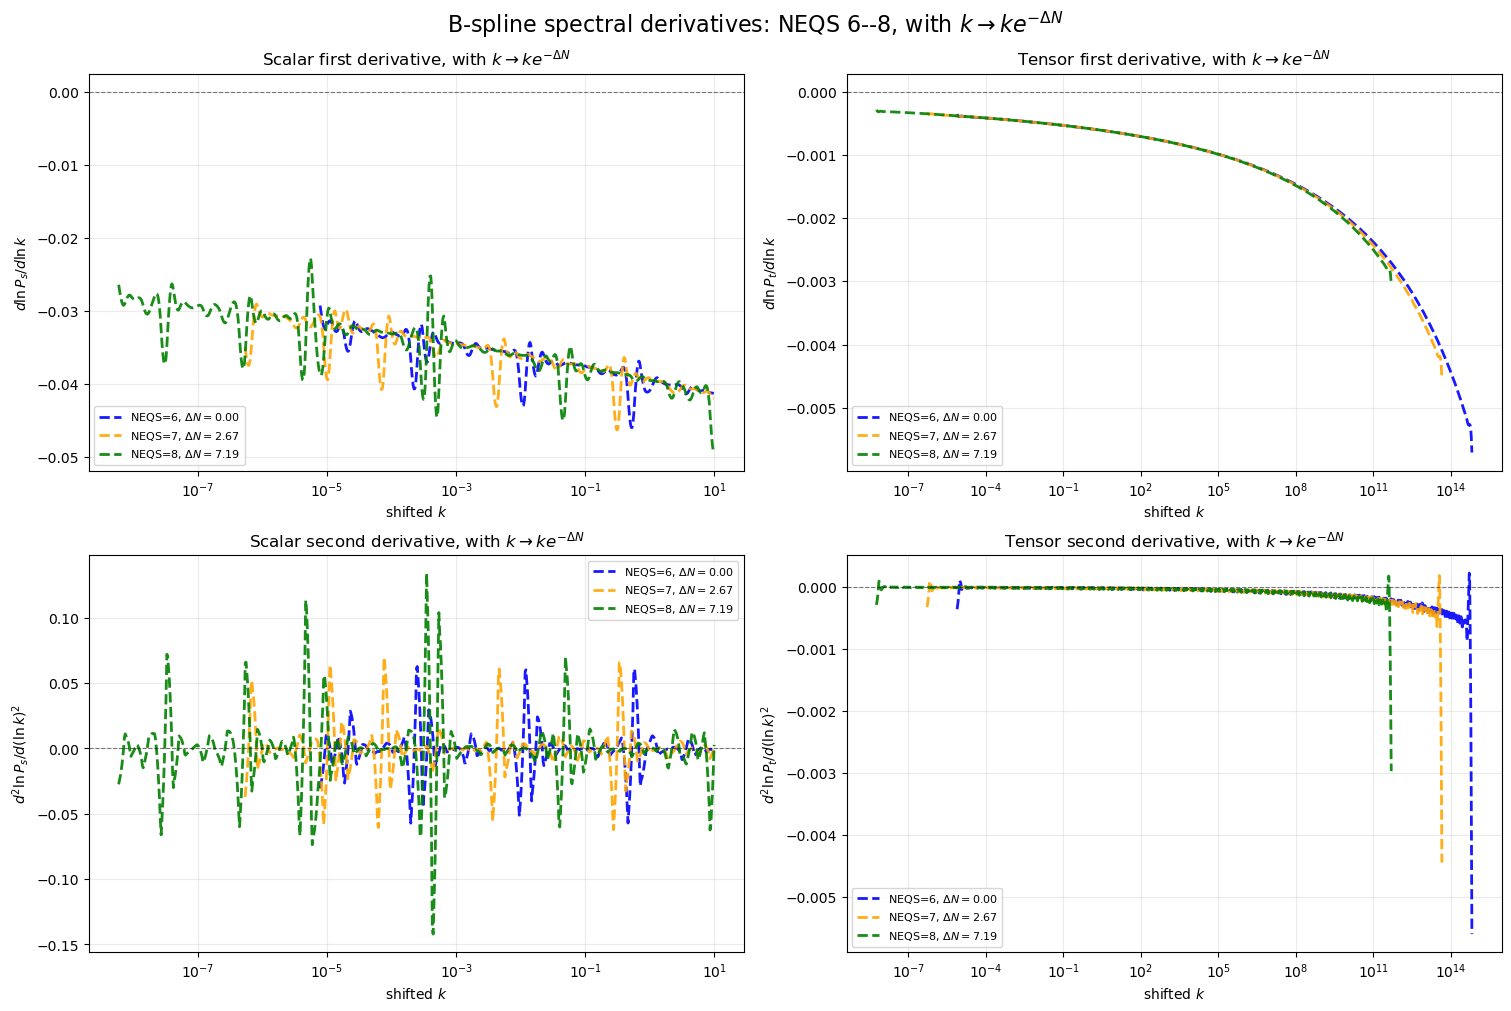

In [132]:
plot_base_spectra_derivatives_bspline_2x2_kshifted(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    apply_k_shift=True,
    k_min_plot=None,
    k_max_plot_s=10.0,
    k_max_plot_t=None,
    smoothing=0.0,
    save_name="base_spectra_derivatives_neqs6_8_kshifted.png",
)

# OBSERVABLE COMPARISONS

In [66]:
def print_base_model_comparison_table(base_summary_df):

    # sort by NEQS just to be safe
    df = base_summary_df.sort_values("NEQS").copy()

    # reference (NEQS=6)
    ref = df[df["NEQS"] == 6].iloc[0]

    # compute differences relative to NEQS=6
    df["delta_N"] = df["original_N_end"] - ref["original_N_end"]
    df["delta_ns"] = df["n_s"] - ref["n_s"]
    df["delta_r"] = df["r"] - ref["r"]

    # percent changes
    df["pct_delta_ns"] = 100 * df["delta_ns"] / ref["n_s"]
    df["pct_delta_r"] = 100 * df["delta_r"] / ref["r"]

    # nice formatting
    display_df = df[[
        "NEQS",
        "param",
        "value",
        "original_N_end",
        "delta_N",
        "n_s",
        "delta_ns",
        "pct_delta_ns",
        "r",
        "delta_r",
        "pct_delta_r",
    ]].copy()

    display_df["value"] = display_df["value"].map(lambda x: f"{x:.3e}")
    display_df["original_N_end"] = display_df["original_N_end"].map(lambda x: f"{x:.3f}")
    display_df["delta_N"] = display_df["delta_N"].map(lambda x: f"{x:+.3f}")

    display_df["n_s"] = display_df["n_s"].map(lambda x: f"{x:.6f}")
    display_df["delta_ns"] = display_df["delta_ns"].map(lambda x: f"{x:+.6f}")
    display_df["pct_delta_ns"] = display_df["pct_delta_ns"].map(lambda x: f"{x:+.3f}%")

    display_df["r"] = display_df["r"].map(lambda x: f"{x:.6f}")
    display_df["delta_r"] = display_df["delta_r"].map(lambda x: f"{x:+.6f}")
    display_df["pct_delta_r"] = display_df["pct_delta_r"].map(lambda x: f"{x:+.3f}%")

    print("\n=== Base Model Comparison (relative to NEQS=6) ===\n")
    print(display_df.to_string(index=False))

    return df


comparison_df = print_base_model_comparison_table(base_summary_df)




=== Base Model Comparison (relative to NEQS=6) ===

 NEQS param      value original_N_end delta_N      n_s  delta_ns pct_delta_ns        r   delta_r pct_delta_r
    6  lam3 -4.610e-06        939.164  +0.000 0.965678 +0.000000      +0.000% 0.003454 +0.000000     +0.000%
    7  lam4  6.871e-08        941.837  +2.673 0.967201 +0.001523      +0.158% 0.003158 -0.000297     -8.588%
    8  lam5 -8.925e-09        946.350  +7.186 0.969485 +0.003807      +0.394% 0.002737 -0.000717    -20.760%
